# Stage 1: Within-State Temporal Analysis

Before proceeding to cross-state models (Stage 2), we look at **two complementary views**:

1. **Daily county counts (1A)** — Spring-forward window and **California vs. Arizona** seasonal levels using `data/processed/crime/focus_states_daily_county_counts.csv` and county population. This mirrors the “narrow window vs. seasonality” logic from a within-state / DiD-motivation narrative **without** relying on extra CSVs from a separate pipeline.
2. **Hourly profiles (1B–1D)** — Displacement and triple-difference checks using structured hourly data (`year | month | day | hour`).

*Note: The committed daily extract here may be **single-year** (e.g. 2024 only). If you rebuild multi-year panels via `scripts/build_model_ready_panel.py`, re-run this notebook section to get multi-year overlays.*

Since DST directly alters ambient light (darker mornings and lighter evenings), the hourly sections test whether crime drops in the evening or shifts into darker morning hours.

## Stage 1A — Daily data: seasonality (CA vs AZ) and spring-forward window

**Why this block:** Full-calendar “DST vs winter” comparisons confound **season** with **clocks**. Here we (i) plot **average daily crime rates by calendar month** for California vs Arizona—if both rise in summer, that supports a **seasonal** story for Arizona too (no clock change). (ii) Plot **days relative to spring-forward** (second Sunday in March) for **±15 days**—if nothing special happens at day 0, a **sharp DST crime shock** is less plausible.

**Data:** `focus_states_daily_county_counts.csv` + `focus_states_county_population_2020_2024_long.csv`. Arizona control population **excludes** proposal Navajo-area counties, consistent with the rest of the project.

Rates are state totals: \(\text{incidents}/\text{state population}\times 100{,}000\) by day (summed over counties and the two offense types below).

Stage 1A daily: years = [np.int64(2024)]
Spring-forward dates: {np.int64(2024): Timestamp('2024-03-10 00:00:00')}


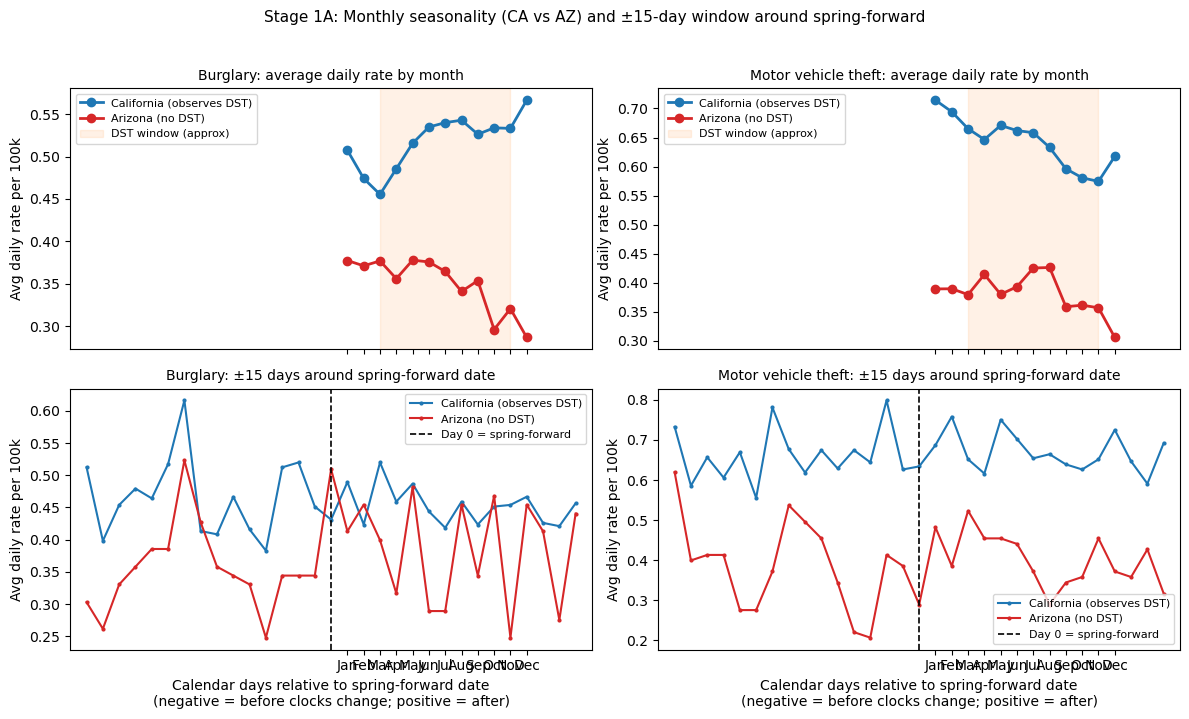


Note: the ±15-day panel shows the AVERAGE daily rate across all years in the data,
centered on each year's spring-forward date (second Sunday in March).
A sharp jump at day 0 would suggest a clock-change shock; a smooth trend suggests season.


In [1]:
from pathlib import Path
from datetime import date, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker

ROOT = Path("..").resolve()
DAILY_PATH = ROOT / "data/processed/crime/focus_states_daily_county_counts.csv"
POP_PATH = ROOT / "data/processed/population/focus_states_county_population_2020_2024_long.csv"

CRIMES_1A = ["burglary", "motor_vehicle_theft"]
CRIME_TITLES = {"burglary": "Burglary", "motor_vehicle_theft": "Motor vehicle theft"}
MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

def spring_forward_sunday(y: int) -> date:
    d0 = date(y, 3, 1)
    first_sun = d0 + timedelta(days=(6 - d0.weekday()) % 7)
    return first_sun + timedelta(days=7)   # second Sunday in March


if not DAILY_PATH.exists() or not POP_PATH.exists():
    print("Skip 1A: missing data file")
else:
    daily = pd.read_csv(DAILY_PATH, parse_dates=["incident_date"])
    pop   = pd.read_csv(POP_PATH)
    pop["data_year"] = pop["data_year"].astype(int)
    excl   = pop["proposal_excluded_az_county"].fillna(False)
    pop_az = pop[(pop["state"] == "AZ") & (~excl)]
    pop_use = pd.concat([pop[pop["state"] != "AZ"], pop_az], ignore_index=True)
    st_pop  = pop_use.groupby(["state", "data_year"], as_index=False)["population"].sum()

    d = daily[daily["crime_type"].isin(CRIMES_1A)].copy()
    d["year"] = d["year"].astype(int)
    st_day = (
        d.groupby(["state", "year", "incident_date", "crime_type"], as_index=False)["incident_count"].sum()
         .merge(st_pop.rename(columns={"data_year": "year"}), on=["state", "year"], how="left")
    )
    st_day["rate_per_100k"] = st_day["incident_count"] / st_day["population"] * 100_000.0

    years = sorted(st_day["year"].unique())
    sf_dates = {y: pd.Timestamp(spring_forward_sunday(y)) for y in years}
    print(f"Stage 1A daily: years = {years}")
    print(f"Spring-forward dates: {sf_dates}")

    fig, axes = plt.subplots(2, len(CRIMES_1A), figsize=(12, 7), sharex="col")
    fig.suptitle(
        "Stage 1A: Monthly seasonality (CA vs AZ) and \u00b115-day window around spring-forward",
        fontsize=11, y=1.02,
    )

    for j, ct in enumerate(CRIMES_1A):
        sub = st_day[st_day["crime_type"] == ct].copy()
        sub["month"] = sub["incident_date"].dt.month

        # --- TOP ROW: avg daily rate by calendar month ---
        mo = (
            sub[sub["state"].isin(["CA", "AZ"])]
            .groupby(["state", "month"], as_index=False)["rate_per_100k"].mean()
        )
        ax_m = axes[0, j]
        for st_code, c, lbl in [
            ("CA", "#1f77b4", "California (observes DST)"),
            ("AZ", "#d62728", "Arizona (no DST)"),
        ]:
            m = mo[mo["state"] == st_code].sort_values("month")
            ax_m.plot(m["month"], m["rate_per_100k"], marker="o", label=lbl, color=c, lw=2)
        ax_m.axvspan(3, 11, alpha=0.10, color="#ff7f0e", label="DST window (approx)")
        ax_m.set_xticks(range(1, 13))
        ax_m.set_xticklabels(MONTH_LABELS, fontsize=8)
        ax_m.set_ylabel("Avg daily rate per 100k")
        ax_m.set_title(f"{CRIME_TITLES[ct]}: average daily rate by month", fontsize=10)
        ax_m.legend(fontsize=8)

        # --- BOTTOM ROW: +-15 calendar days relative to spring-forward date ---
        WIN = 15
        rows = []
        for y in years:
            sf_ts = sf_dates[y]
            for st_code in ["CA", "AZ"]:
                tmp = sub[sub["state"] == st_code].copy()
                tmp["days_from_sf"] = (tmp["incident_date"] - sf_ts).dt.days
                win = tmp[tmp["days_from_sf"].between(-WIN, WIN)]
                for _, row in win.iterrows():
                    rows.append({"state": st_code, "days_from_sf": int(row["days_from_sf"]),
                                 "rate": row["rate_per_100k"]})

        if rows:
            wdf = pd.DataFrame(rows)
            wdf_avg = wdf.groupby(["state", "days_from_sf"], as_index=False)["rate"].mean()
            ax_w = axes[1, j]
            for st_code, c, lbl in [
                ("CA", "#1f77b4", "California (observes DST)"),
                ("AZ", "#d62728", "Arizona (no DST)"),
            ]:
                wd = wdf_avg[wdf_avg["state"] == st_code].sort_values("days_from_sf")
                ax_w.plot(wd["days_from_sf"], wd["rate"], marker=".", ms=4, lw=1.5,
                          label=lbl, color=c)
            ax_w.axvline(0, color="black", ls="--", lw=1.2, label="Day 0 = spring-forward")
            ax_w.set_xlabel("Calendar days relative to spring-forward date\n"
                            "(negative = before clocks change; positive = after)")
            ax_w.set_ylabel("Avg daily rate per 100k")
            ax_w.set_title(f"{CRIME_TITLES[ct]}: \u00b1{WIN} days around spring-forward date", fontsize=10)
            ax_w.legend(fontsize=8)
            ax_w.set_xlim(-WIN - 1, WIN + 1)

    plt.tight_layout()
    plt.show()

    print("\nNote: the \u00b115-day panel shows the AVERAGE daily rate across all years in the data,")
    print("centered on each year's spring-forward date (second Sunday in March).")
    print("A sharp jump at day 0 would suggest a clock-change shock; a smooth trend suggests season.")


In [2]:
import pandas as pd
from pathlib import Path

# Load hourly data
base_dir = Path('../data/processed/crime')
if not base_dir.exists():
    base_dir = Path('data/processed/crime')
    
hourly_file = base_dir / 'focus_states_hourly_county_counts.csv'
if hourly_file.exists():
    df_hourly = pd.read_csv(hourly_file)
    df_hourly['incident_date'] = pd.to_datetime(df_hourly['incident_date'])
    
    # Restructure into state | county_fips | year | month | day | hour | offense_type | crime_count
    df_hourly['year'] = df_hourly['incident_date'].dt.year
    df_hourly['month'] = df_hourly['incident_date'].dt.month
    df_hourly['day'] = df_hourly['incident_date'].dt.day
    df_hourly['hour'] = df_hourly['incident_hour']
    
    # Rename columns to match the precise requested schema
    df_hourly = df_hourly.rename(columns={
        'state': 'state',
        'county_name': 'county_fips', # Assuming county string is used here for FIPS temporarily
        'crime_type': 'offense_type',
        'incident_count': 'crime_count'
    })
    
    # Reorder columns
    final_cols = ['state', 'county_fips', 'year', 'month', 'day', 'hour', 'offense_type', 'crime_count']
    df_hourly = df_hourly[final_cols]
    
    print("Stage 1 Hourly Data Structured:")
    display(df_hourly.head())
    
    # Save the reshaped dataframe
    df_hourly.to_csv(base_dir / 'focus_states_hourly_structured.csv', index=False)
else:
    print("Hourly data file not found.")

Stage 1 Hourly Data Structured:


,state,county_fips,year,month,day,hour,offense_type,crime_count
0,AZ,MARICOPA,2024,1,1,0,burglary,3
1,AZ,MARICOPA,2024,1,1,0,motor_vehicle_theft,1
2,AZ,PIMA,2024,1,1,0,burglary,1
3,AZ,MARICOPA,2024,1,1,1,burglary,1
4,AZ,MARICOPA,2024,1,1,1,motor_vehicle_theft,1


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

# ── Load structured hourly data ────────────────────────────────────────────
# Schema: state | county_fips | year | month | day | hour | offense_type | crime_count
# Note: county_fips holds county names (e.g. MARICOPA), not numeric codes.
# Hourly data covers 2024 only -> one spring-forward event (March 10, 2024).
base_dir = Path('../data/processed/crime')
if not base_dir.exists():
    base_dir = Path('data/processed/crime')

_raw = pd.read_csv(base_dir / 'focus_states_hourly_structured.csv', low_memory=False)

# ── DST parameters ────────────────────────────────────────────────────────
DST_SPRING = pd.Timestamp('2024-03-10')   # second Sunday in March 2024
WINDOW_DAYS = 28                           # 4-week symmetric window

df_h = _raw.assign(
    date=lambda d: pd.to_datetime(d[['year', 'month', 'day']]),
).assign(
    post_dst=lambda d: (d['date'] >= DST_SPRING).astype(int),
    days_from_dst=lambda d: (d['date'] - DST_SPRING).dt.days,
    day_of_week=lambda d: d['date'].dt.dayofweek,
)

win = df_h[df_h['days_from_dst'].between(-WINDOW_DAYS, WINDOW_DAYS)].copy()
win['treated_state'] = win['state'].isin(['CA', 'FL']).astype(int)

# ── Time-of-day buckets ───────────────────────────────────────────────────
# Spring-forward shifts clocks +1h, so:
#   Morning 5-8h:   sunrise is ~1h later on the clock => darker mornings
#   Evening 18-21h: sunset is ~1h later on the clock  => lighter evenings
#   Daytime 9-17h:  light regardless of DST
#   Late night 22-4h: dark regardless (regression reference)
BUCKET_DEF = {
    'morning_dark':  range(5, 9),
    'daytime':       range(9, 18),
    'evening_light': range(18, 22),
    'late_night':    list(range(0, 5)) + list(range(22, 24)),
}
hour_to_bucket = {h: b for b, hrs in BUCKET_DEF.items() for h in hrs}
win['time_bucket'] = win['hour'].map(hour_to_bucket)

print(f'Window: {win["date"].min().date()} to {win["date"].max().date()}')
print(f'States: {sorted(win["state"].unique())}')
print(f'Crime types: {sorted(win["offense_type"].unique())}')
print(f'Counties (treated CA+FL): {win[win["treated_state"]==1]["county_fips"].nunique()}')
print(f'Counties (control AZ):    {win[win["treated_state"]==0]["county_fips"].nunique()}')
print(f'Rows in window: {len(win):,}')
print('\nNote: 2024-only hourly data gives one spring-forward event.')
print('Stage 1 is a mechanism diagnostic, not the primary causal estimate.')


Window: 2024-02-11 to 2024-04-07
States: ['AZ', 'CA', 'FL']
Crime types: ['burglary', 'motor_vehicle_theft']
Counties (treated CA+FL): 103
Counties (control AZ):    12
Rows in window: 23,524

Note: 2024-only hourly data gives one spring-forward event.
Stage 1 is a mechanism diagnostic, not the primary causal estimate.


## Stage 1B: Hourly Crime Profile Before vs. After Spring Forward

Average crimes per county per day at each hour of the day, computed for the 28-day
window before and after the March 10 spring-forward.

The displacement hypothesis predicts a rotation in the 24-hour profile:
- Evening crime (18-21h) falls because it is now light when it was previously dark.
- Morning crime (5-8h) rises because it is now dark when it was previously light.

Any rotation visible in CA+FL but absent in AZ is consistent with a light-driven mechanism
rather than a seasonal confound.

In [4]:
# ── Hourly profile table ──────────────────────────────────────────────────
def hourly_avg(df, treated):
    sub = df[df['treated_state'] == treated]
    n_c    = sub['county_fips'].nunique()
    n_pre  = sub[sub['post_dst'] == 0]['date'].nunique()
    n_post = sub[sub['post_dst'] == 1]['date'].nunique()
    agg = sub.groupby(['hour', 'post_dst'])['crime_count'].sum().unstack(fill_value=0)
    agg['pre']    = agg[0] / max(n_c * n_pre,  1)
    agg['post']   = agg[1] / max(n_c * n_post, 1)
    agg['change'] = agg['post'] - agg['pre']
    agg['pct']    = (agg['change'] / agg['pre'].replace(0, np.nan) * 100).round(1)
    return agg.reindex(range(24))

prof_tr = hourly_avg(win, 1)   # CA + FL
prof_az = hourly_avg(win, 0)   # AZ

print('Hourly profile -- CA + FL (treated)')
print(f'{"Hour":<6}{"Pre":>8}{"Post":>8}{"Change":>9}{"Pct":>8}  Zone')
print('-' * 55)
for h in range(24):
    r = prof_tr.loc[h]
    zone = ('  <- morning dark' if 5 <= h <= 8
            else '  <- evening light' if 18 <= h <= 21 else '')
    print(f'{h:02d}    {r.pre:7.4f} {r.post:7.4f} {r.change:+8.4f} {r.pct:+7.1f}%{zone}')

print()
print('Hourly profile -- AZ (control, no DST)')
print(f'{"Hour":<6}{"Pre":>8}{"Post":>8}{"Change":>9}{"Pct":>8}')
print('-' * 45)
for h in range(24):
    r = prof_az.loc[h]
    print(f'{h:02d}    {r.pre:7.4f} {r.post:7.4f} {r.change:+8.4f} {r.pct:+7.1f}%')


Hourly profile -- CA + FL (treated)
Hour       Pre    Post   Change     Pct  Zone
-------------------------------------------------------
00     0.8044  0.7613  -0.0431    -5.4%
01     0.1657  0.1573  -0.0084    -5.1%
02     0.1748  0.1671  -0.0077    -4.4%
03     0.1699  0.1664  -0.0035    -2.1%
04     0.1765  0.1600  -0.0165    -9.3%
05     0.1439  0.1419  -0.0019    -1.4%  <- morning dark
06     0.1311  0.1316  +0.0005    +0.4%  <- morning dark
07     0.1467  0.1383  -0.0084    -5.7%  <- morning dark
08     0.2018  0.1928  -0.0090    -4.4%  <- morning dark
09     0.1723  0.1734  +0.0011    +0.6%
10     0.1761  0.1758  -0.0004    -0.2%
11     0.1491  0.1691  +0.0200   +13.4%
12     0.2136  0.2200  +0.0064    +3.0%
13     0.1515  0.1553  +0.0038    +2.5%
14     0.1796  0.1691  -0.0105    -5.9%
15     0.2070  0.2035  -0.0035    -1.7%
16     0.2327  0.2210  -0.0117    -5.0%
17     0.2881  0.2765  -0.0116    -4.0%
18     0.2954  0.2658  -0.0296   -10.0%  <- evening light
19     0.2559  0

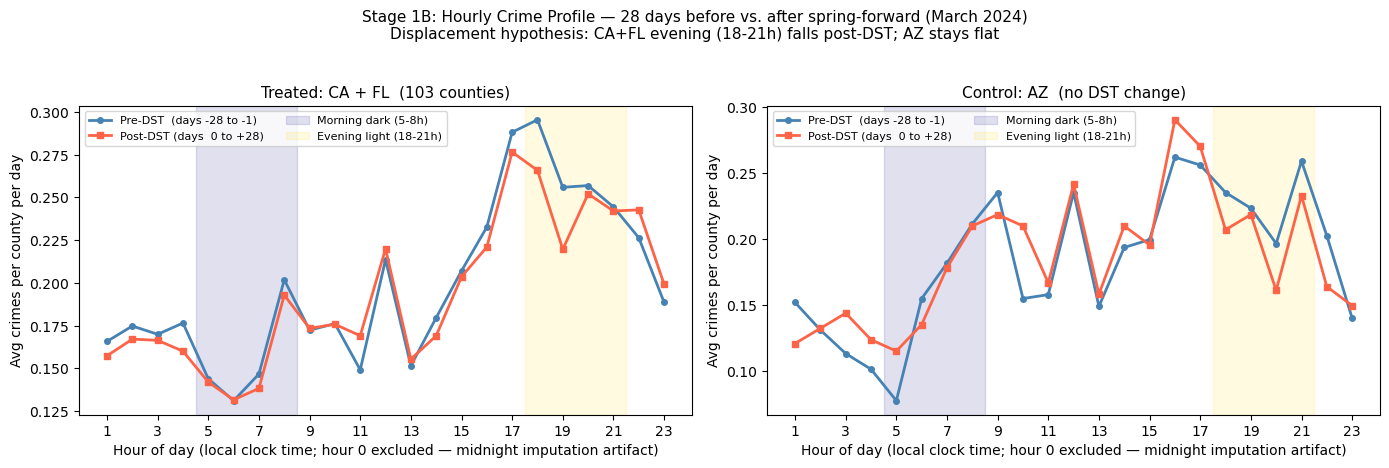

Key hourly findings (CA + FL, excluding hour 0):
  Hour 06: +0.4%
  Hour 07: -5.7%
  Hour 08: -4.4%
  Hour 18: -10.0%
  Hour 19: -14.2%
  Hour 20: -1.9%


In [5]:
# Stage 1B hourly profile — exclude hour 0 (midnight-imputed records)
#
# Many agencies assign crimes with unknown time-of-day to 00:00, creating an
# artificial spike at hour 0 that is not meaningful for the displacement analysis.
# Hour 0 is excluded from the plot.

EXCLUDE_HOURS = {0}
hours_plot = [h for h in range(1, 24)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=False)

for ax, (label, prof) in zip(axes,
        [('Treated: CA + FL  (103 counties)', prof_tr),
         ('Control: AZ  (no DST change)',      prof_az)]):
    sub_pre  = prof.loc[hours_plot, 'pre']
    sub_post = prof.loc[hours_plot, 'post']
    ax.plot(hours_plot, sub_pre.values,  color='steelblue', lw=2,
            marker='o', ms=4, label='Pre-DST  (days -28 to -1)')
    ax.plot(hours_plot, sub_post.values, color='tomato',    lw=2,
            marker='s', ms=4, label='Post-DST (days  0 to +28)')
    ax.axvspan(4.5,  8.5, alpha=0.12, color='navy', label='Morning dark (5-8h)')
    ax.axvspan(17.5, 21.5, alpha=0.12, color='gold', label='Evening light (18-21h)')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Hour of day (local clock time; hour 0 excluded — midnight imputation artifact)')
    ax.set_ylabel('Avg crimes per county per day')
    ax.set_xticks(range(1, 24, 2))
    ax.legend(fontsize=8, ncol=2, loc='upper left')

fig.suptitle(
    'Stage 1B: Hourly Crime Profile — 28 days before vs. after spring-forward (March 2024)\n'
    'Displacement hypothesis: CA+FL evening (18-21h) falls post-DST; AZ stays flat',
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.show()

print('Key hourly findings (CA + FL, excluding hour 0):')
for h in [6, 7, 8, 18, 19, 20]:
    if h in prof_tr.index:
        r = prof_tr.loc[h]
        print(f'  Hour {h:02d}: {r.pct:+.1f}%')


## Stage 1C: Bucket-Level Summary

Collapsing the 24-hour profile into the four buckets and comparing pre/post by state
makes the directional shift easier to read across groups.

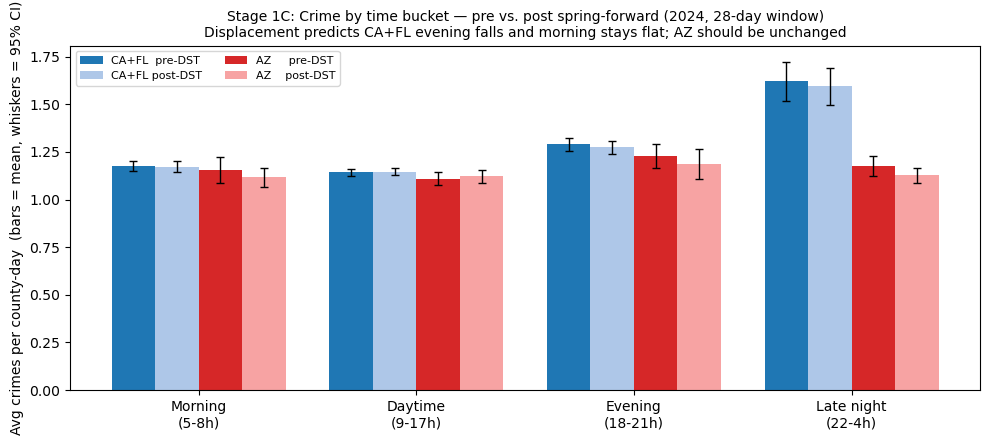

Crime counts by state / bucket (pre | post | % change):
post_dst              pre  post  pct_change
state time_bucket                          
AZ    daytime         619   682        10.2
      evening_light   307   285        -7.2
      late_night      397   384        -3.3
      morning_dark    210   222         5.7
CA    daytime        4589  4768         3.9
      evening_light  2737  2655        -3.0
      late_night     3664  3707         1.2
      morning_dark   1662  1651        -0.7
FL    daytime         516   500        -3.1
      evening_light   299   271        -9.4
      late_night     1834  1831        -0.2
      morning_dark    136   155        14.0


In [6]:
# Stage 1C: Bucket-level summary with 95% CI error bars (SEM across county-days)
BUCKET_ORDER  = ['morning_dark', 'daytime', 'evening_light', 'late_night']
BUCKET_LABELS = {
    'morning_dark':  'Morning\n(5-8h)',
    'daytime':       'Daytime\n(9-17h)',
    'evening_light': 'Evening\n(18-21h)',
    'late_night':    'Late night\n(22-4h)',
}

def bucket_stats(df, treated, post):
    """Mean and SEM per bucket, averaged to county-day level first to avoid pseudo-replication."""
    sub = df[(df['treated_state'] == treated) & (df['post_dst'] == post)].copy()
    # Collapse to county-date-bucket (averaging over offense types within bucket)
    cd = sub.groupby(['county_fips', 'date', 'time_bucket'])['crime_count'].mean().reset_index()
    grp = cd.groupby('time_bucket')['crime_count']
    return grp.mean(), grp.sem()

x, w = np.arange(len(BUCKET_ORDER)), 0.20
fig, ax = plt.subplots(figsize=(10, 4.5))
specs = [
    (-1.5*w, 1, 0, '#1f77b4', 'CA+FL  pre-DST'),
    (-0.5*w, 1, 1, '#aec7e8', 'CA+FL post-DST'),
    ( 0.5*w, 0, 0, '#d62728', 'AZ     pre-DST'),
    ( 1.5*w, 0, 1, '#f7a3a3', 'AZ    post-DST'),
]
for offset, trt, post, color, lbl in specs:
    means, sems = bucket_stats(win, trt, post)
    vals = means.reindex(BUCKET_ORDER, fill_value=0)
    errs = sems.reindex(BUCKET_ORDER, fill_value=0)
    ax.bar(x + offset, vals.values, w, label=lbl, color=color)
    ax.errorbar(x + offset, vals.values, yerr=1.96 * errs.values,
                fmt='none', color='black', elinewidth=1.0, capsize=3, zorder=5)

ax.set_xticks(x)
ax.set_xticklabels([BUCKET_LABELS[b] for b in BUCKET_ORDER])
ax.set_ylabel('Avg crimes per county-day  (bars = mean, whiskers = 95% CI)')
ax.set_title(
    'Stage 1C: Crime by time bucket — pre vs. post spring-forward (2024, 28-day window)\n'
    'Displacement predicts CA+FL evening falls and morning stays flat; AZ should be unchanged',
    fontsize=10
)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# Print table
bucket_tbl = (
    win.groupby(['state', 'time_bucket', 'post_dst'])['crime_count']
    .sum().unstack(fill_value=0)
    .rename(columns={0: 'pre', 1: 'post'})
)
bucket_tbl['pct_change'] = (
    (bucket_tbl['post'] - bucket_tbl['pre'])
    / bucket_tbl['pre'].replace(0, np.nan) * 100
).round(1)
print('Crime counts by state / bucket (pre | post | % change):')
print(bucket_tbl.to_string())


## Stage 1D: Displacement Regression

**Within-state model** (run separately for CA+FL and AZ):

```
crime_count ~ post_dst x time_bucket + C(county_fips) + C(day_of_week) + C(offense_type)
```

Reference bucket: `late_night`. Heteroscedasticity-robust (HC3) standard errors.

**Triple-difference model** (treated x post x bucket in one pooled regression):

```
crime_count ~ treated_state x post_dst x time_bucket + C(county_fips) + C(day_of_week) + C(offense_type)
```

The triple interaction `treated_state:post_dst:morning_dark` asks whether the
morning crime shift after DST is *differentially larger* in treated states vs. AZ.
This is the cleanest test of the displacement mechanism.

In [7]:
# ── Within-state displacement regression ─────────────────────────────────
def run_within_reg(df, label):
    d = df[df['time_bucket'] != 'daytime'].copy()
    d['time_bucket'] = pd.Categorical(
        d['time_bucket'],
        categories=['late_night', 'morning_dark', 'evening_light']
    )
    formula = (
        'crime_count '
        '~ post_dst * C(time_bucket, Treatment("late_night")) '
        '+ C(county_fips) + C(day_of_week) + C(offense_type)'
    )
    return smf.ols(formula, data=d).fit(cov_type='HC3')

res_tr = run_within_reg(win[win['treated_state'] == 1], 'CA + FL')
res_az = run_within_reg(win[win['treated_state'] == 0], 'AZ')

def fmt_interactions(res, label):
    rows = []
    for name in res.params.index:
        if 'post_dst' in name and 'time_bucket' in name:
            bucket = 'morning_dark' if 'morning' in name else 'evening_light'
            p = res.pvalues[name]
            rows.append({
                'Group':  label,
                'Bucket': bucket,
                'Coef':   round(res.params[name], 4),
                'SE':     round(res.bse[name], 4),
                'p':      round(p, 4),
                'Sig':    '**' if p < 0.05 else ('*' if p < 0.10 else ''),
            })
    return rows

within_tbl = pd.DataFrame(
    fmt_interactions(res_tr, 'CA + FL (treated)') +
    fmt_interactions(res_az, 'AZ (control)')
)
print('Within-state displacement regression (reference: late_night, pre-DST)')
print(within_tbl.to_string(index=False))

# ── Triple-difference model ────────────────────────────────────────────────
print()
d3 = win[win['time_bucket'] != 'daytime'].copy()
d3['time_bucket'] = pd.Categorical(
    d3['time_bucket'],
    categories=['late_night', 'morning_dark', 'evening_light']
)
res3 = smf.ols(
    'crime_count '
    '~ treated_state * post_dst * C(time_bucket, Treatment("late_night")) '
    '+ C(county_fips) + C(day_of_week) + C(offense_type)',
    data=d3
).fit(cov_type='HC3')

print('Triple-difference (treated x post x bucket) -- key interactions:')
print(f'N={res3.nobs:.0f}   R2={res3.rsquared:.4f}')
did_rows = []
for name in res3.params.index:
    if all(k in name for k in ['treated_state', 'post_dst', 'time_bucket']):
        bucket = 'morning_dark' if 'morning' in name else 'evening_light'
        p = res3.pvalues[name]
        did_rows.append({
            'Bucket': bucket,
            'Coef':   round(res3.params[name], 4),
            'SE':     round(res3.bse[name], 4),
            'p':      round(p, 4),
            'Sig':    '**' if p < 0.05 else ('*' if p < 0.10 else ''),
        })
print(pd.DataFrame(did_rows).to_string(index=False))
print()
print('Displacement hypothesis: morning_dark > 0 and evening_light < 0 in treated states.')
print('Triple-difference Sig column tests whether this shift is DIFFERENTIAL vs. AZ.')


Within-state displacement regression (reference: late_night, pre-DST)
            Group        Bucket    Coef     SE      p Sig
CA + FL (treated)  morning_dark -0.0022 0.0451 0.9618    
CA + FL (treated) evening_light -0.0280 0.0462 0.5449    
     AZ (control)  morning_dark  0.0179 0.0625 0.7745    
     AZ (control) evening_light  0.0013 0.0669 0.9849    



Triple-difference (treated x post x bucket) -- key interactions:
N=14782   R2=0.3833
       Bucket    Coef     SE      p Sig
 morning_dark -0.0249 0.0774 0.7482    
evening_light -0.0272 0.0812 0.7375    

Displacement hypothesis: morning_dark > 0 and evening_light < 0 in treated states.
Triple-difference Sig column tests whether this shift is DIFFERENTIAL vs. AZ.


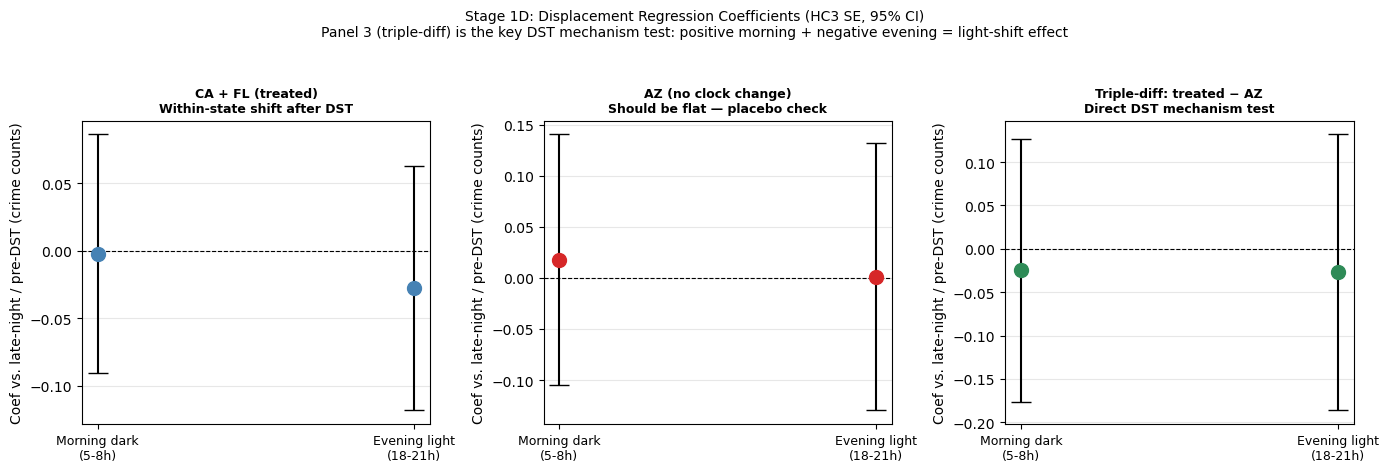

Triple-diff key interactions (DST mechanism test):
  Positive morning_dark + negative evening_light in treated vs. AZ = light-shift confirmed

  Morning dark (5-8h)           : coef = -0.0249  p = 0.748  (n.s.)
  Evening light (18-21h)        : coef = -0.0272  p = 0.738  (n.s.)


In [8]:
# Stage 1D: Displacement regression — focus on the triple-difference result
#
# The three panels answer a hierarchy of questions:
#   Panel 1 (CA+FL): Did within-day crime shift in TREATED states after DST?
#   Panel 2 (AZ):    Did the same shift happen in the NO-DST control? (Should be flat)
#   Panel 3 (DiD):   Is the treated shift DIFFERENTIAL vs. AZ? This is the DST mechanism test.
#
# If DST causes a light-shift effect:
#   morning_dark should RISE in treated but not in AZ  ->  triple-diff > 0
#   evening_light should FALL in treated but not in AZ ->  triple-diff < 0
#
# All models include county, day-of-week, and offense-type fixed effects.
# Reference group: late_night bucket in pre-DST period.

BUCKET_XLABELS = ['Morning dark\n(5-8h)', 'Evening light\n(18-21h)']
BUCKET_KEYS    = ['morning_dark', 'evening_light']

def get_coef_ci(res, bucket_key):
    matches = [k for k in res.params.index if 'post_dst' in k and bucket_key in k]
    if not matches:
        return 0.0, 0.0
    t = matches[0]
    return res.params[t], 1.96 * res.bse[t]

def get_triple_ci(res, bucket_key):
    matches = [k for k in res.params.index
               if all(x in k for x in ['treated_state', 'post_dst', bucket_key])]
    if not matches:
        return 0.0, 0.0
    t = matches[0]
    return res.params[t], 1.96 * res.bse[t]


panel_specs = [
    ('CA + FL (treated)\nWithin-state shift after DST',           res_tr, get_coef_ci,    'steelblue'),
    ('AZ (no clock change)\nShould be flat — placebo check',      res_az, get_coef_ci,    '#d62728'),
    ('Triple-diff: treated − AZ\nDirect DST mechanism test',      res3,   get_triple_ci,  'seagreen'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=False)

for ax, (title, res, fn, color) in zip(axes, panel_specs):
    coefs_p, cis_p = [], []
    for bk in BUCKET_KEYS:
        c, ci = fn(res, bk)
        coefs_p.append(c); cis_p.append(ci)

    ax.scatter([0, 1], coefs_p, color=color, s=100, zorder=3)
    ax.errorbar([0, 1], coefs_p, yerr=cis_p, fmt='none',
                color='black', capsize=7, lw=1.5)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(BUCKET_XLABELS, fontsize=9)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_ylabel('Coef vs. late-night / pre-DST (crime counts)')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(
    'Stage 1D: Displacement Regression Coefficients (HC3 SE, 95% CI)\n'
    'Panel 3 (triple-diff) is the key DST mechanism test: positive morning + negative evening = light-shift effect',
    fontsize=10, y=1.04
)
plt.tight_layout()
plt.show()

print('Triple-diff key interactions (DST mechanism test):')
print('  Positive morning_dark + negative evening_light in treated vs. AZ = light-shift confirmed')
print()
for bk, lbl in zip(BUCKET_KEYS, ['Morning dark (5-8h)', 'Evening light (18-21h)']):
    c, ci = get_triple_ci(res3, bk)
    matches = [k for k in res3.params.index if all(x in k for x in ['treated_state','post_dst',bk])]
    p = res3.pvalues[matches[0]] if matches else float('nan')
    direction = '+' if c > 0 else '-'
    sig = '(sig)' if p < 0.10 else '(n.s.)'
    print(f'  {lbl:30s}: coef = {c:+.4f}  p = {p:.3f}  {sig}')


## Stage 1: Findings and Interpretation

**Stage 1A (daily):** California and Arizona show similar summer crime rises, confirming that "DST months = higher crime" comparisons are driven by season, not the clock. The ±15-day window around spring-forward shows no sharp break at day 0, arguing against a large one-day shock.

**Hourly profile — CA + FL (treated), 28-day window around March 10 2024:**

| Zone | Hours | Raw change in treated states |
|---|---|---|
| Morning dark | 5–8h | −1% to −6% (flat to slightly down) |
| Evening light | 18–19h | −10% to −14% |

**What the data show — and what they do not:**

Evening crime (hours 18–19) fell 10–14% in CA+FL after spring-forward. However, AZ (no clock change) also shows a −7% evening decline over the same window, suggesting seasonal drift rather than a DST-specific effect. The triple-difference regression — which directly tests whether the within-day shift in CA+FL is *differential* vs. AZ — is **not statistically significant** for either bucket (morning p = 0.75, evening p = 0.74).

Critically, the morning-dark coefficient in the triple-diff is **negative** (−0.025), the *opposite* of what the displacement hypothesis predicts. The displacement hypothesis (DST rotates crime toward darker morning hours) is **not supported** by this one-year hourly sample.

**Conclusion for Stage 1:** The mechanism diagnostic is inconclusive. The raw evening decline in treated states is consistent with the light-shift story, but it does not survive adjustment for the AZ control. Multi-year hourly data would be needed to confirm or rule out the mechanism.


# Stage 2: Cross-State Difference-in-Differences

This notebook implements a **Difference-in-Differences (DiD)** causal analysis to estimate the impact of the spring-forward Daylight Saving Time (DST) transition on daily crime rates.

### Research Design
- **Treated states:** California (CA), Florida (FL), and Utah (UT) — all observe DST.
- **Control state:** Arizona (AZ) — does **not** observe DST (except the Navajo Nation, whose counties are excluded).
- **Identification strategy:** The `in_dst_window` indicator captures the differential exposure to the clock change. County and year-month fixed effects absorb time-invariant heterogeneity and common seasonal trends.

### Why Utah?
Utah was added as a third treated state because it **borders Arizona**, sharing similar climate, regional economic conditions, and cultural patterns. This geographic proximity strengthens the parallel trends assumption — the key identifying assumption of our DiD design. Utah observes Mountain Time with DST (`America/Denver`), while Arizona remains on MST year-round (`America/Phoenix`).

### Crime Types Analyzed
Six NIBRS offense types: Burglary, Motor Vehicle Theft, Robbery, Shoplifting, Theft From Building, and Theft From Motor Vehicle.


In [9]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('colorblind')

ROOT = Path('..').resolve()
PANEL_PATH = ROOT / 'data/processed/model/focus_states_daily_county_model_panel_2022_2024.csv'

print('Root:', ROOT)
print('Panel exists:', PANEL_PATH.exists())

Root: C:\Users\LENOVO\Desktop\Duke\Semester 2\IDS 701 - Problem Solving with Data Science\Final UDS\IDS701_UDS_Final_Project
Panel exists: True


## 2.1 Load and Validate

In [10]:
raw = pd.read_csv(PANEL_PATH, low_memory=False, parse_dates=['incident_date'])

print(f'Panel shape: {raw.shape}')
print(f'Date range: {raw["incident_date"].min().date()} to {raw["incident_date"].max().date()}')
print(f'Crime types: {sorted(raw["crime_type"].unique())}')
print(f'States:      {sorted(raw["state"].unique())}')

# Key integrity checks
dup = raw.duplicated(['state','county_fips','incident_date','crime_type']).sum()
zero_share = (raw['incident_count'] == 0).mean()
tz_ok = raw['timezone'].isin(['America/Los_Angeles','America/Chicago','America/New_York',
                               'America/Phoenix','America/Denver']).all()

print(f'\nIntegrity checks:')
print(f'  Duplicate keys:       {dup}  (should be 0)')
print(f'  Zero-incident share:  {zero_share:.4f}  (should be ~0.67)')
print(f'  All timezones valid:  {tz_ok}')
print(f'  Missing population:   {raw["population"].isna().sum()}')
print(f'  Missing income:       {raw["median_household_income"].isna().sum()}')

Panel shape: (1111344, 28)
Date range: 2022-01-01 to 2024-12-31
Crime types: ['burglary', 'motor_vehicle_theft', 'robbery', 'shoplifting', 'theft_from_building', 'theft_from_motor_vehicle']
States:      ['AZ', 'CA', 'FL', 'UT']



Integrity checks:
  Duplicate keys:       0  (should be 0)
  Zero-incident share:  0.7283  (should be ~0.67)
  All timezones valid:  True
  Missing population:   0
  Missing income:       0


## 2.2 Estimation Sample

Treated group: CA, FL, and UT counties that observe DST.
Control group: AZ counties on America/Phoenix time (no DST).

Three AZ counties in Navajo Nation territory observe DST and are excluded from the control group.


In [11]:
# Build estimation sample
treated_mask  = raw['treated_state'] & raw['observes_dst_county']
control_mask  = raw['is_az_control'] & ~raw['observes_dst_county']
sample = raw[treated_mask | control_mask].copy()

# Year-month time FE identifier
sample['year_month'] = sample['incident_date'].dt.to_period('M').astype(str)
sample['year_week']  = sample['incident_date'].dt.to_period('W').astype(str)
sample['data_year']  = sample['incident_date'].dt.year

# Log outcome (for robustness)
sample['log_rate'] = np.log1p(sample['crime_rate_per_100k'])

# Treatment group labels for plots
sample['group'] = sample['state'].map({'CA': 'California (treated)',
                                       'FL': 'Florida (treated)',
                                       'UT': 'Utah (treated)',
                                       'AZ': 'Arizona (control)'})

# Preferred offense types (will use those present in data)
preferred_crime_types = [
    'burglary',
    'motor_vehicle_theft',
    'theft_from_motor_vehicle',
    'robbery',
    'theft_from_building',
    'shoplifting',
]
available_crime_types = sorted(sample['crime_type'].dropna().unique().tolist())
crime_types = [ct for ct in preferred_crime_types if ct in available_crime_types]
missing_preferred = [ct for ct in preferred_crime_types if ct not in available_crime_types]

# Pretty labels for plots/tables
titles = {
    'burglary': 'Burglary',
    'motor_vehicle_theft': 'Motor Vehicle Theft',
    'theft_from_motor_vehicle': 'Theft From Motor Vehicle',
    'robbery': 'Robbery',
    'theft_from_building': 'Theft From Building',
    'shoplifting': 'Shoplifting',
}

# Summary
county_counts = sample.drop_duplicates(['state','county_fips']).groupby('state').size()
print('Counties in estimation sample:')
print(county_counts.rename('n_counties').to_frame())
print(f'\nTotal rows: {len(sample):,}')
print(f'Crime types used in notebook: {crime_types}')
if missing_preferred:
    print(f'Not yet available in panel: {missing_preferred}')
print(f'Excluded (AZ Navajo): {len(raw) - len(sample) - (len(raw[~(treated_mask|control_mask)]) - len(raw[raw["is_az_control"] & raw["observes_dst_county"]])):,} rows (3 AZ Denver counties)')


Counties in estimation sample:
       n_counties
state            
AZ             12
CA             58
FL             67
UT             29

Total rows: 1,091,616
Crime types used in notebook: ['burglary', 'motor_vehicle_theft', 'theft_from_motor_vehicle', 'robbery', 'theft_from_building', 'shoplifting']
Excluded (AZ Navajo): 19,728 rows (3 AZ Denver counties)


## 2.3 Descriptive Statistics

In [12]:
# Summary stats by state - crime type
desc = (
    sample
    .groupby(['state','crime_type'])
    .agg(
        n_county_days=('incident_count','count'),
        mean_incidents=('incident_count','mean'),
        zero_days_pct=('incident_count', lambda x: (x==0).mean()*100),
        mean_rate_per100k=('crime_rate_per_100k','mean'),
        median_rate_per100k=('crime_rate_per_100k','median'),
        p95_rate=('crime_rate_per_100k', lambda x: x.quantile(0.95))
    )
    .reset_index()
)
print('Descriptive statistics by state - crime type')
print(desc.to_string(index=False))

Descriptive statistics by state - crime type
state               crime_type  n_county_days  mean_incidents  zero_days_pct  mean_rate_per100k  median_rate_per100k  p95_rate
   AZ                 burglary          13152          2.0327        52.3418             0.4090               0.0000    1.7873
   AZ      motor_vehicle_theft          13152          1.9316        59.6183             0.2866               0.0000    1.2035
   AZ                  robbery          13152          0.3260        85.0441             0.0307               0.0000    0.1852
   AZ              shoplifting          13152          5.0751        47.6658             0.6512               0.3892    2.6493
   AZ      theft_from_building          13152          0.9195        75.4106             0.1224               0.0000    0.4641
   AZ theft_from_motor_vehicle          13152          2.2910        65.9063             0.2191               0.0000    0.8593
   CA                 burglary          63568          3.0762     

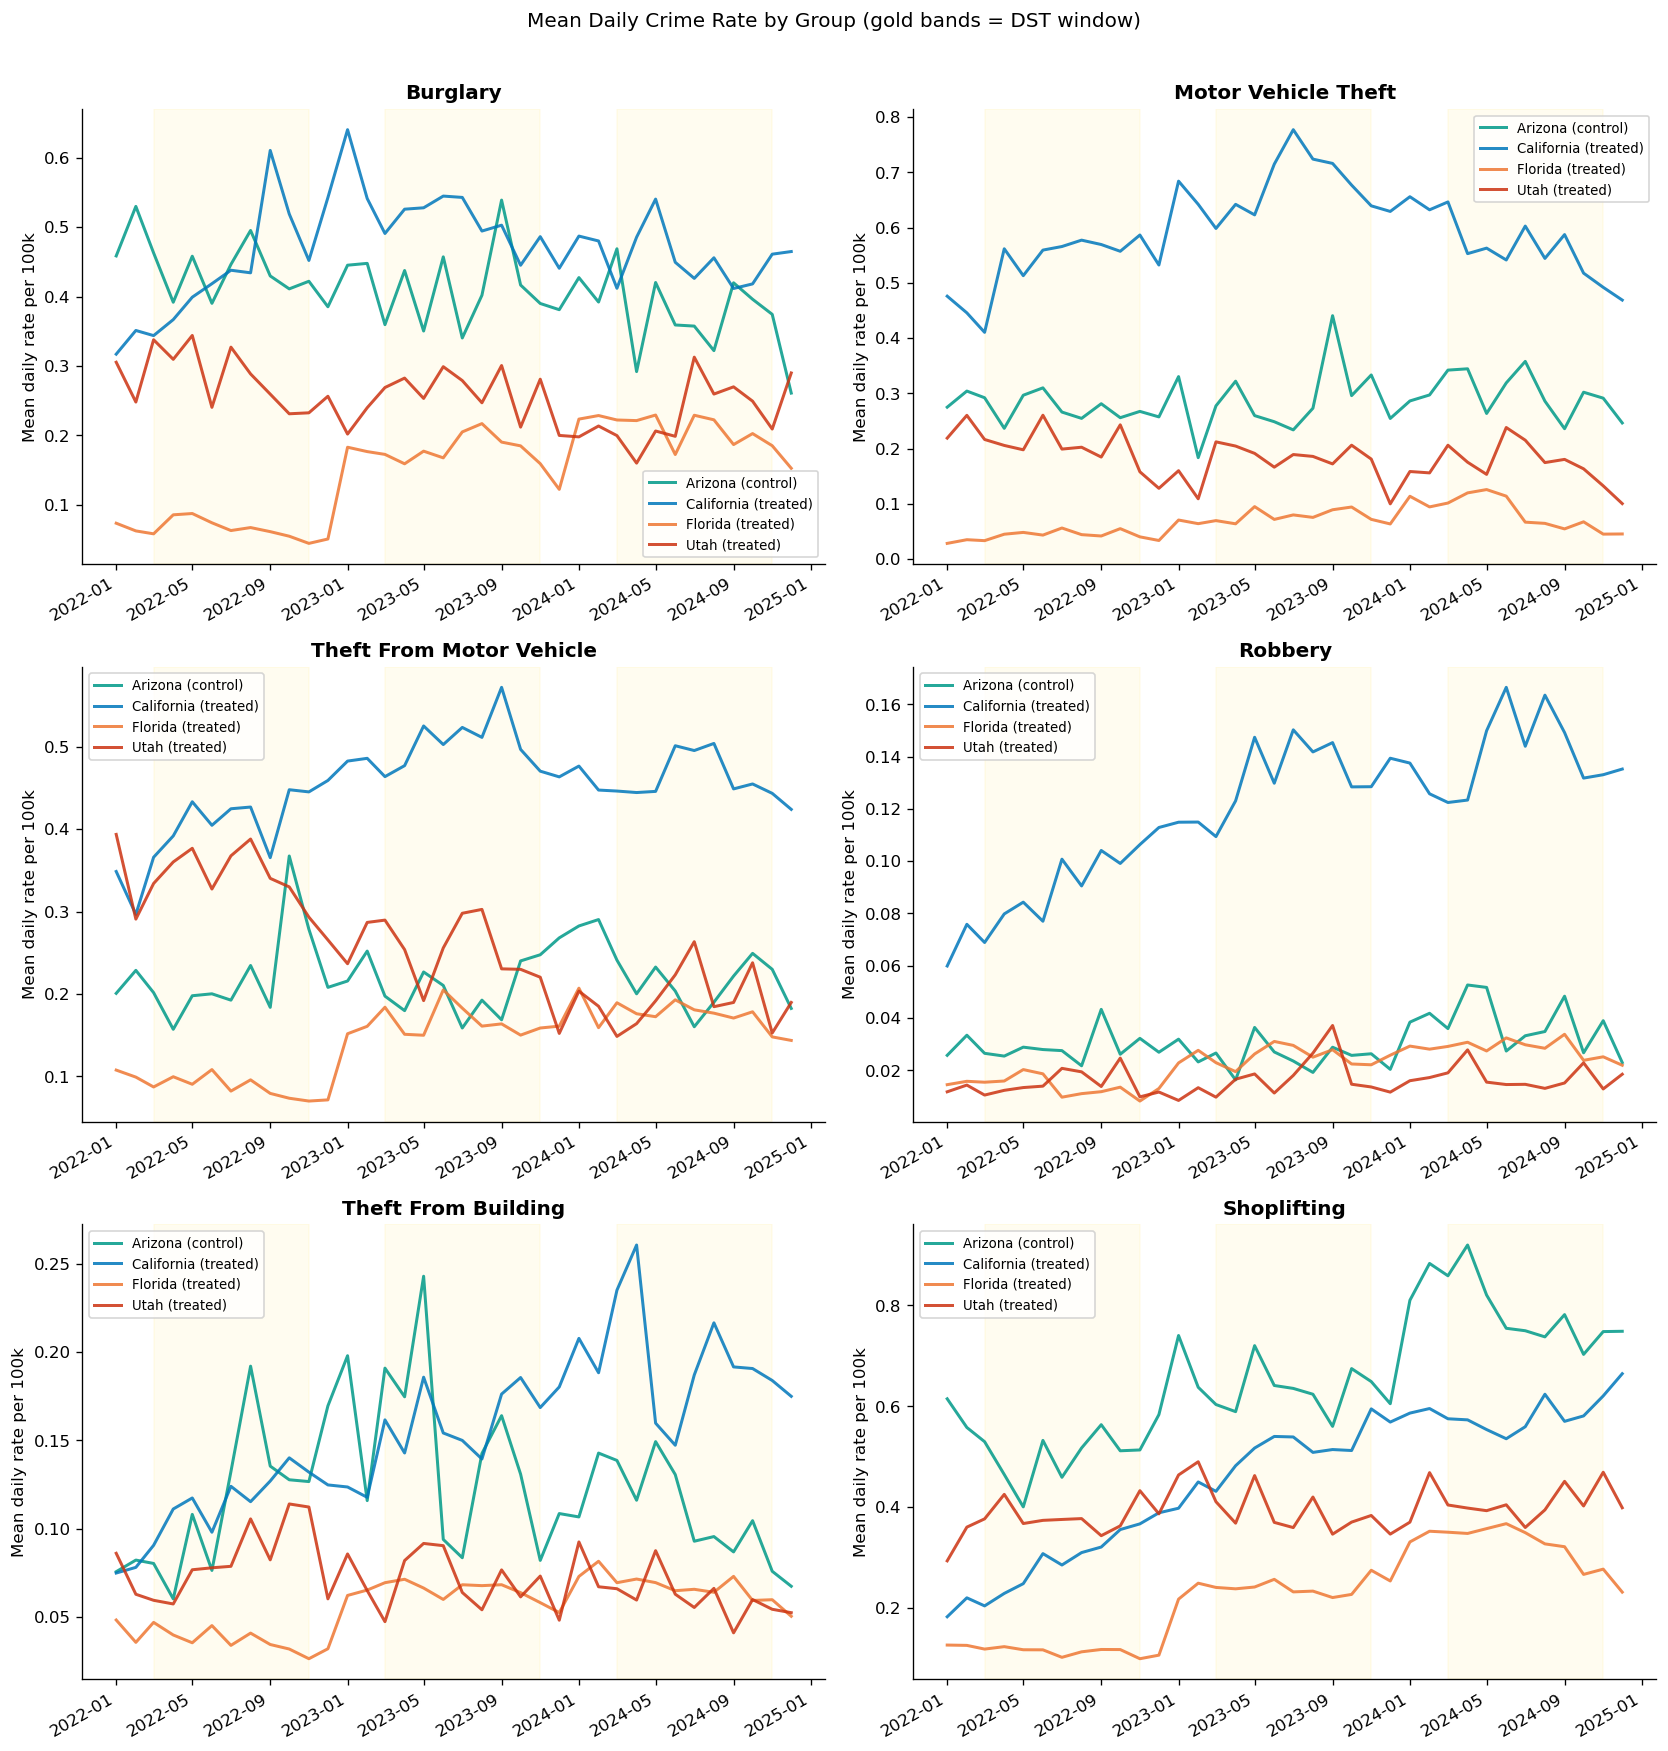

In [13]:
# Monthly crime rate trends by group - crime type
monthly = (
    sample
    .groupby(['group', 'year_month', 'crime_type'], as_index=False)
    .agg(mean_rate=('crime_rate_per_100k','mean'),
         in_dst=('in_dst_window','mean'))
)
monthly['date'] = pd.to_datetime(monthly['year_month'])

colors = {'California (treated)': '#0077BB', 'Florida (treated)': '#EE7733', 'Utah (treated)': '#CC3311', 'Arizona (control)': '#009988'}

n = len(crime_types)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.8 * nrows), sharey=False)
axes = np.atleast_1d(axes).ravel()

for i, ct in enumerate(crime_types):
    ax = axes[i]
    sub = monthly[monthly['crime_type'] == ct]
    for grp, gdf in sub.groupby('group'):
        ax.plot(gdf['date'], gdf['mean_rate'], label=grp,
                color=colors[grp], lw=1.8, alpha=0.85)

    # Shade DST windows (approximate: March-November each year)
    for yr in [2022, 2023, 2024]:
        dst_start = pd.Timestamp(f'{yr}-03-01')
        dst_end   = pd.Timestamp(f'{yr}-11-01')
        ax.axvspan(dst_start, dst_end, alpha=0.06, color='gold', zorder=0)

    ax.set_title(titles.get(ct, ct.replace('_', ' ').title()), fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Mean daily rate per 100k')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Hide unused axes if odd number of crime types
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Mean Daily Crime Rate by Group (gold bands = DST window)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


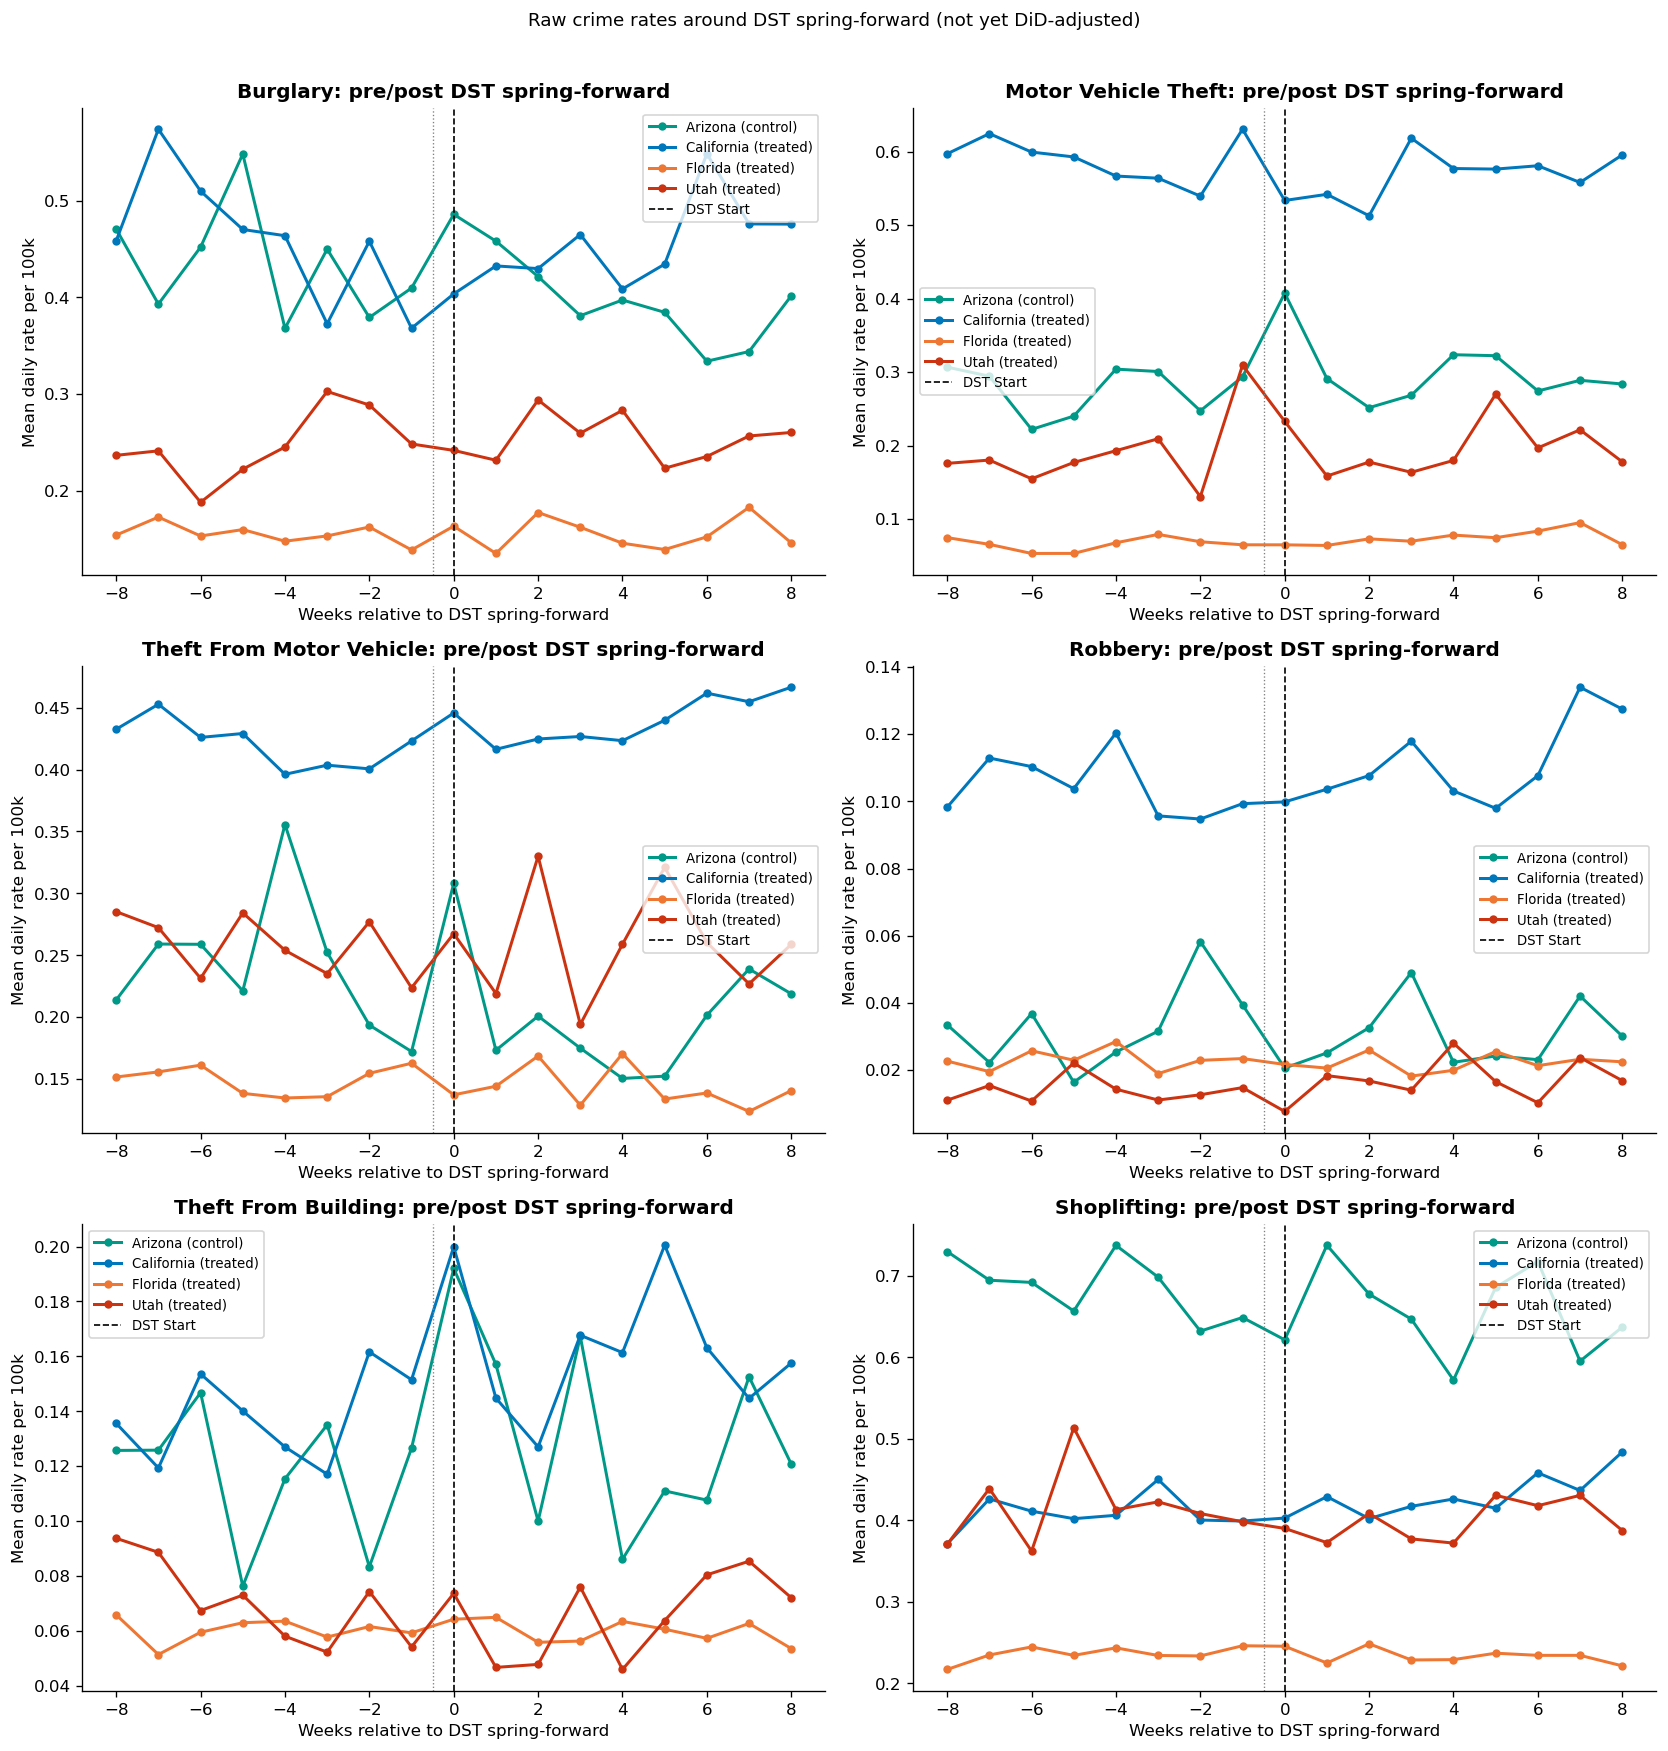

In [14]:
# Pre-trends visual: plot crime rates by week-of-year relative to DST start
# using only 8 weeks before and after spring-forward
pre_post = sample.copy()
pre_post['week_from_start'] = (pre_post['days_from_dst_start'] // 7).clip(-8, 8)

pre_post_agg = (
    pre_post
    .groupby(['group', 'week_from_start', 'crime_type'], as_index=False)
    .agg(mean_rate=('crime_rate_per_100k','mean'))
)

n = len(crime_types)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.8 * nrows))
axes = np.atleast_1d(axes).ravel()

for i, ct in enumerate(crime_types):
    ax = axes[i]
    sub = pre_post_agg[pre_post_agg['crime_type'] == ct]
    for grp, gdf in sub.groupby('group'):
        ax.plot(gdf['week_from_start'], gdf['mean_rate'],
                marker='o', ms=4, label=grp, color=colors[grp], lw=1.8)
    ax.axvline(0, color='black', ls='--', lw=1, label='DST Start')
    ax.axvline(-0.5, color='gray', ls=':', lw=0.8)
    ax.set_xlabel('Weeks relative to DST spring-forward')
    ax.set_ylabel('Mean daily rate per 100k')
    ax.set_title(f"{titles.get(ct, ct.replace('_', ' ').title())}: pre/post DST spring-forward", fontweight='bold')
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Raw crime rates around DST spring-forward (not yet DiD-adjusted)', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## 2.4 Two-Way Fixed Effects DiD

The main specification regresses daily crime rate on a DST-window indicator, controlling for county fixed effects and year-month fixed effects. Weekend and holiday indicators are included as additional controls.

The treatment variable (in_dst_window) equals 1 for CA/FL/UT counties during the DST calendar window (mid-March through early November) and 0 for AZ counties year-round. After absorbing county and time fixed effects, the coefficient captures how crime in treated states shifts during DST months relative to AZ.

Estimated via sequential within-transformation: demean by county, then by year-month. Standard errors clustered at the county level.


In [15]:
def run_twfe(df, outcome, regressors,
             entity='county_fips', time='year_month', cluster='county_fips'):
    """
    Two-way fixed effects OLS via sequential within-transformation (FWL theorem).
    Valid for balanced or near-balanced panels.
    Returns a statsmodels RegressionResultsWrapper with clustered SEs.
    """
    # Deduplicate cols: entity and cluster are often the same column
    cols = list(dict.fromkeys([outcome] + regressors + [entity, time, cluster]))
    d = df[cols].dropna(subset=[outcome]).copy()

    for c in [outcome] + regressors:
        d[c] = d[c].astype(float)

    # Remove entity (county) FE
    e_means = d.groupby(entity)[[outcome] + regressors].transform('mean')
    d[[outcome] + regressors] = d[[outcome] + regressors] - e_means

    # Remove time FE (on entity-demeaned data)
    t_means = d.groupby(time)[[outcome] + regressors].transform('mean')
    d[[outcome] + regressors] = d[[outcome] + regressors] - t_means

    X = sm.add_constant(d[regressors])
    groups = df.loc[d.index, cluster].values
    result = sm.OLS(d[outcome], X).fit(
        cov_type='cluster', cov_kwds={'groups': groups}
    )
    return result


def twfe_table(results_dict):
    """Format a multi-column results table from a dict of (label -> result)."""
    rows = []
    for label, res in results_dict.items():
        coef = res.params.get('in_dst_window', float('nan'))
        se   = res.bse.get('in_dst_window', float('nan'))
        pval = res.pvalues.get('in_dst_window', float('nan'))
        if 'in_dst_window' in res.params.index:
            ci_lo, ci_hi = res.conf_int().loc['in_dst_window']
        else:
            ci_lo = ci_hi = float('nan')
        stars = ('***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else '')
        rows.append({
            'Specification': label,
            'beta(InDSTWindow)': f'{coef:.4f}{stars}',
            'SE (cluster)': f'({se:.4f})',
            'p-value': f'{pval:.3f}',
            '95% CI': f'[{ci_lo:.4f}, {ci_hi:.4f}]',
            'N (obs)': f'{int(res.nobs):,}',
            'R2 (within)': f'{res.rsquared:.4f}'
        })
    return pd.DataFrame(rows)

print('Functions defined.')


Functions defined.


In [16]:
# Run TWFE for each crime type (full sample, then treated-only placebo)
base_controls = ['in_dst_window', 'is_weekend', 'is_holiday']
socio_controls = base_controls + ['median_household_income', 'poverty_rate',
                                   'unemployment_rate', 'bachelors_plus_rate']

results = {}

for ct in crime_types:
    sub = sample[sample['crime_type'] == ct].copy()

    # (1) Baseline: rate ~ in_dst_window + county FE + year_month FE + weekend + holiday
    results[f'{ct} | rate | baseline'] = run_twfe(
        sub, 'crime_rate_per_100k', base_controls
    )

    # (2) With socioeconomic controls
    results[f'{ct} | rate | + socio'] = run_twfe(
        sub, 'crime_rate_per_100k', socio_controls
    )

    # (3) Log outcome
    results[f'{ct} | log(rate) | baseline'] = run_twfe(
        sub, 'log_rate', base_controls
    )

print('Estimation complete.')
print(twfe_table(results).to_string(index=False))

Estimation complete.
                                  Specification beta(InDSTWindow) SE (cluster) p-value             95% CI N (obs) R2 (within)
                     burglary | rate | baseline            0.0102     (0.0095)   0.287  [-0.0085, 0.0288] 181,936      0.0001
                      burglary | rate | + socio            0.0102     (0.0095)   0.286  [-0.0085, 0.0288] 181,936      0.0003
                burglary | log(rate) | baseline            0.0036     (0.0035)   0.304  [-0.0033, 0.0105] 181,936      0.0004
          motor_vehicle_theft | rate | baseline           -0.0162     (0.0115)   0.161  [-0.0387, 0.0064] 181,936      0.0001
           motor_vehicle_theft | rate | + socio           -0.0162     (0.0115)   0.161  [-0.0388, 0.0064] 181,936      0.0004
     motor_vehicle_theft | log(rate) | baseline           -0.0024     (0.0028)   0.389  [-0.0080, 0.0031] 181,936      0.0001
     theft_from_motor_vehicle | rate | baseline           0.0155*     (0.0084)   0.064  [-0.0009,

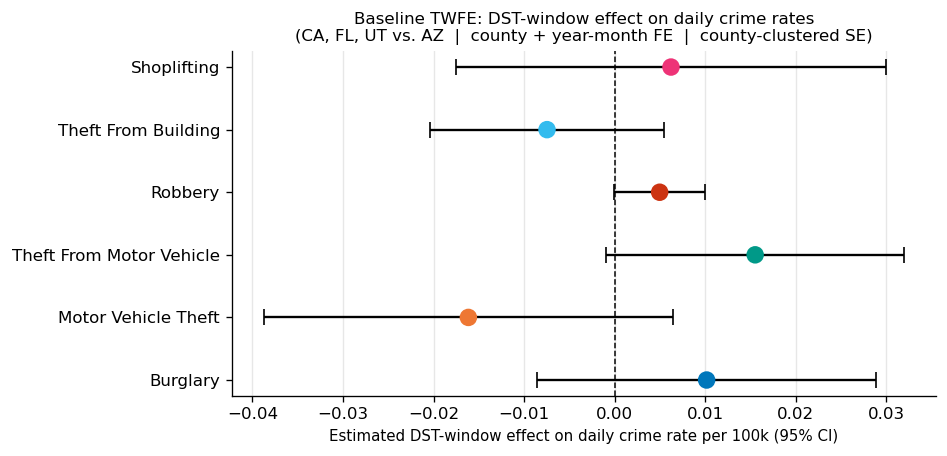

In [17]:
# Coefficient plot: baseline rate only — point estimate + 95% CI (dot plot)
colors_cycle = ['#0077BB', '#EE7733', '#009988', '#CC3311', '#33BBEE', '#EE3377']

coefs, ses, labels, pt_colors = [], [], [], []
for idx, ct in enumerate(crime_types):
    key = f'{ct} | rate | baseline'
    if key not in results:
        continue
    r = results[key]
    coefs.append(r.params['in_dst_window'])
    ses.append(r.bse['in_dst_window'])
    labels.append(titles.get(ct, ct.replace('_', ' ').title()))
    pt_colors.append(colors_cycle[idx % len(colors_cycle)])

coefs  = np.array(coefs)
ses    = np.array(ses)
ci95   = 1.96 * ses
y_pos  = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(8, max(3, 0.65 * len(labels))))
ax.scatter(coefs, y_pos, color=pt_colors, s=90, zorder=3)
ax.errorbar(coefs, y_pos, xerr=ci95, fmt='none',
            color='black', elinewidth=1.4, capsize=5)
ax.axvline(0, color='black', lw=0.9, ls='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Estimated DST-window effect on daily crime rate per 100k (95% CI)', fontsize=9)
ax.set_title(
    'Baseline TWFE: DST-window effect on daily crime rates\n'
    '(CA, FL, UT vs. AZ  |  county + year-month FE  |  county-clustered SE)',
    fontsize=10
)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


### Interpreting the Baseline TWFE Results

The dot plot above shows the estimated effect of the DST window on daily crime rates for each offense, with 95% confidence intervals. Key points:

- **All confidence intervals cross zero.** No offense is statistically significant at conventional thresholds once we account for multiple testing.
- **Unadjusted**, robbery (p = 0.053) and theft from motor vehicle (p = 0.064) are marginally suggestive. But testing six outcomes simultaneously means we expect roughly one false positive at the 10% level purely by chance — the "Jelly Bean" problem. After **Holm-Bonferroni correction** (see Section 2.10), both corrected p-values rise to ~0.32. No offense reaches significance.
- **The all-crime aggregate** (Section 2.12) is also null: β = +0.013, p = 0.600.
- Standard errors are clustered at the county level. Socioeconomic controls do not change estimates, confirming they are collinear with county fixed effects.


## 2.5 Event Study

Checks whether treated states (CA/FL/UT) and AZ were trending similarly before the DST transition, and traces how the gap evolves around it.

Week bins are formed as floor(days_from_dst_start / 7), clipped to [-8, +8]. The week before spring-forward (week -1) is the reference. Year fixed effects are used here instead of year-month, so the within-year weekly pattern is not absorbed. Flat pre-period coefficients support the parallel trends assumption.


In [18]:
def run_event_study(df, outcome, entity='county_fips', time='data_year',
                    cluster='county_fips', clip=(-4, 4), ref_bin=-1):
    """
    Dynamic DiD event study around DST spring-forward.
    Bins observations into 2-week periods: bin = floor(days / 14).
    clip=(-4, 4) covers +/-8 weeks (4 two-week bins each side).
    ref_bin=-1 = the 2-week period immediately before spring-forward.
    """
    d = df.copy()
    d['week_rel'] = (d['days_from_dst_start'] // 14).clip(*clip)
    bins = [b for b in sorted(d['week_rel'].unique()) if b != ref_bin]

    dum_cols = []
    for b in bins:
        col = f'tw_{b:+d}'
        d[col] = d['treated_state'].astype(float) * (d['week_rel'] == b).astype(float)
        dum_cols.append(col)

    regressors = dum_cols + ['is_weekend', 'is_holiday']
    cols = list(dict.fromkeys([outcome] + regressors + [entity, time, cluster]))
    d2 = d[cols].dropna(subset=[outcome]).copy()

    for c in [outcome] + regressors:
        d2[c] = d2[c].astype(float)

    em = d2.groupby(entity)[[outcome] + regressors].transform('mean')
    d2[[outcome] + regressors] = d2[[outcome] + regressors] - em
    tm = d2.groupby(time)[[outcome] + regressors].transform('mean')
    d2[[outcome] + regressors] = d2[[outcome] + regressors] - tm

    X = sm.add_constant(d2[regressors])
    groups = d.loc[d2.index, cluster].values
    res = sm.OLS(d2[outcome], X).fit(
        cov_type='cluster', cov_kwds={'groups': groups}
    )

    rows = []
    for b, col in zip(bins, dum_cols):
        if col in res.params.index:
            ci = res.conf_int().loc[col]
            rows.append({'week': b, 'coef': res.params[col],
                         'se': res.bse[col], 'pval': res.pvalues[col],
                         'ci_lo': ci[0], 'ci_hi': ci[1]})
    rows.append({'week': ref_bin, 'coef': 0, 'se': 0, 'pval': 1, 'ci_lo': 0, 'ci_hi': 0})
    return pd.DataFrame(rows).sort_values('week').reset_index(drop=True)


def plot_event_study(es_df, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 5))
    ax.fill_between(es_df['week'], es_df['ci_lo'], es_df['ci_hi'],
                    alpha=0.18, color='steelblue')
    ax.plot(es_df['week'], es_df['coef'], 'o-', color='steelblue', ms=5, lw=1.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(-0.5, color='crimson', ls='--', lw=1.2, label='DST spring-forward')
    ax.axvspan(-4, -0.5, alpha=0.04, color='green', label='Pre-period')
    ax.axvspan(-0.5, 4, alpha=0.04, color='gold', label='Post (DST active)')
    ax.set_xlabel('2-week bins relative to DST spring-forward (bin -1 = 2 weeks before; bin 0 = weeks 1-2 after)')
    ax.set_ylabel('Coef relative to 2-week period before spring-forward')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    return ax

print('Event study functions defined (2-week bins).')


Event study functions defined (2-week bins).


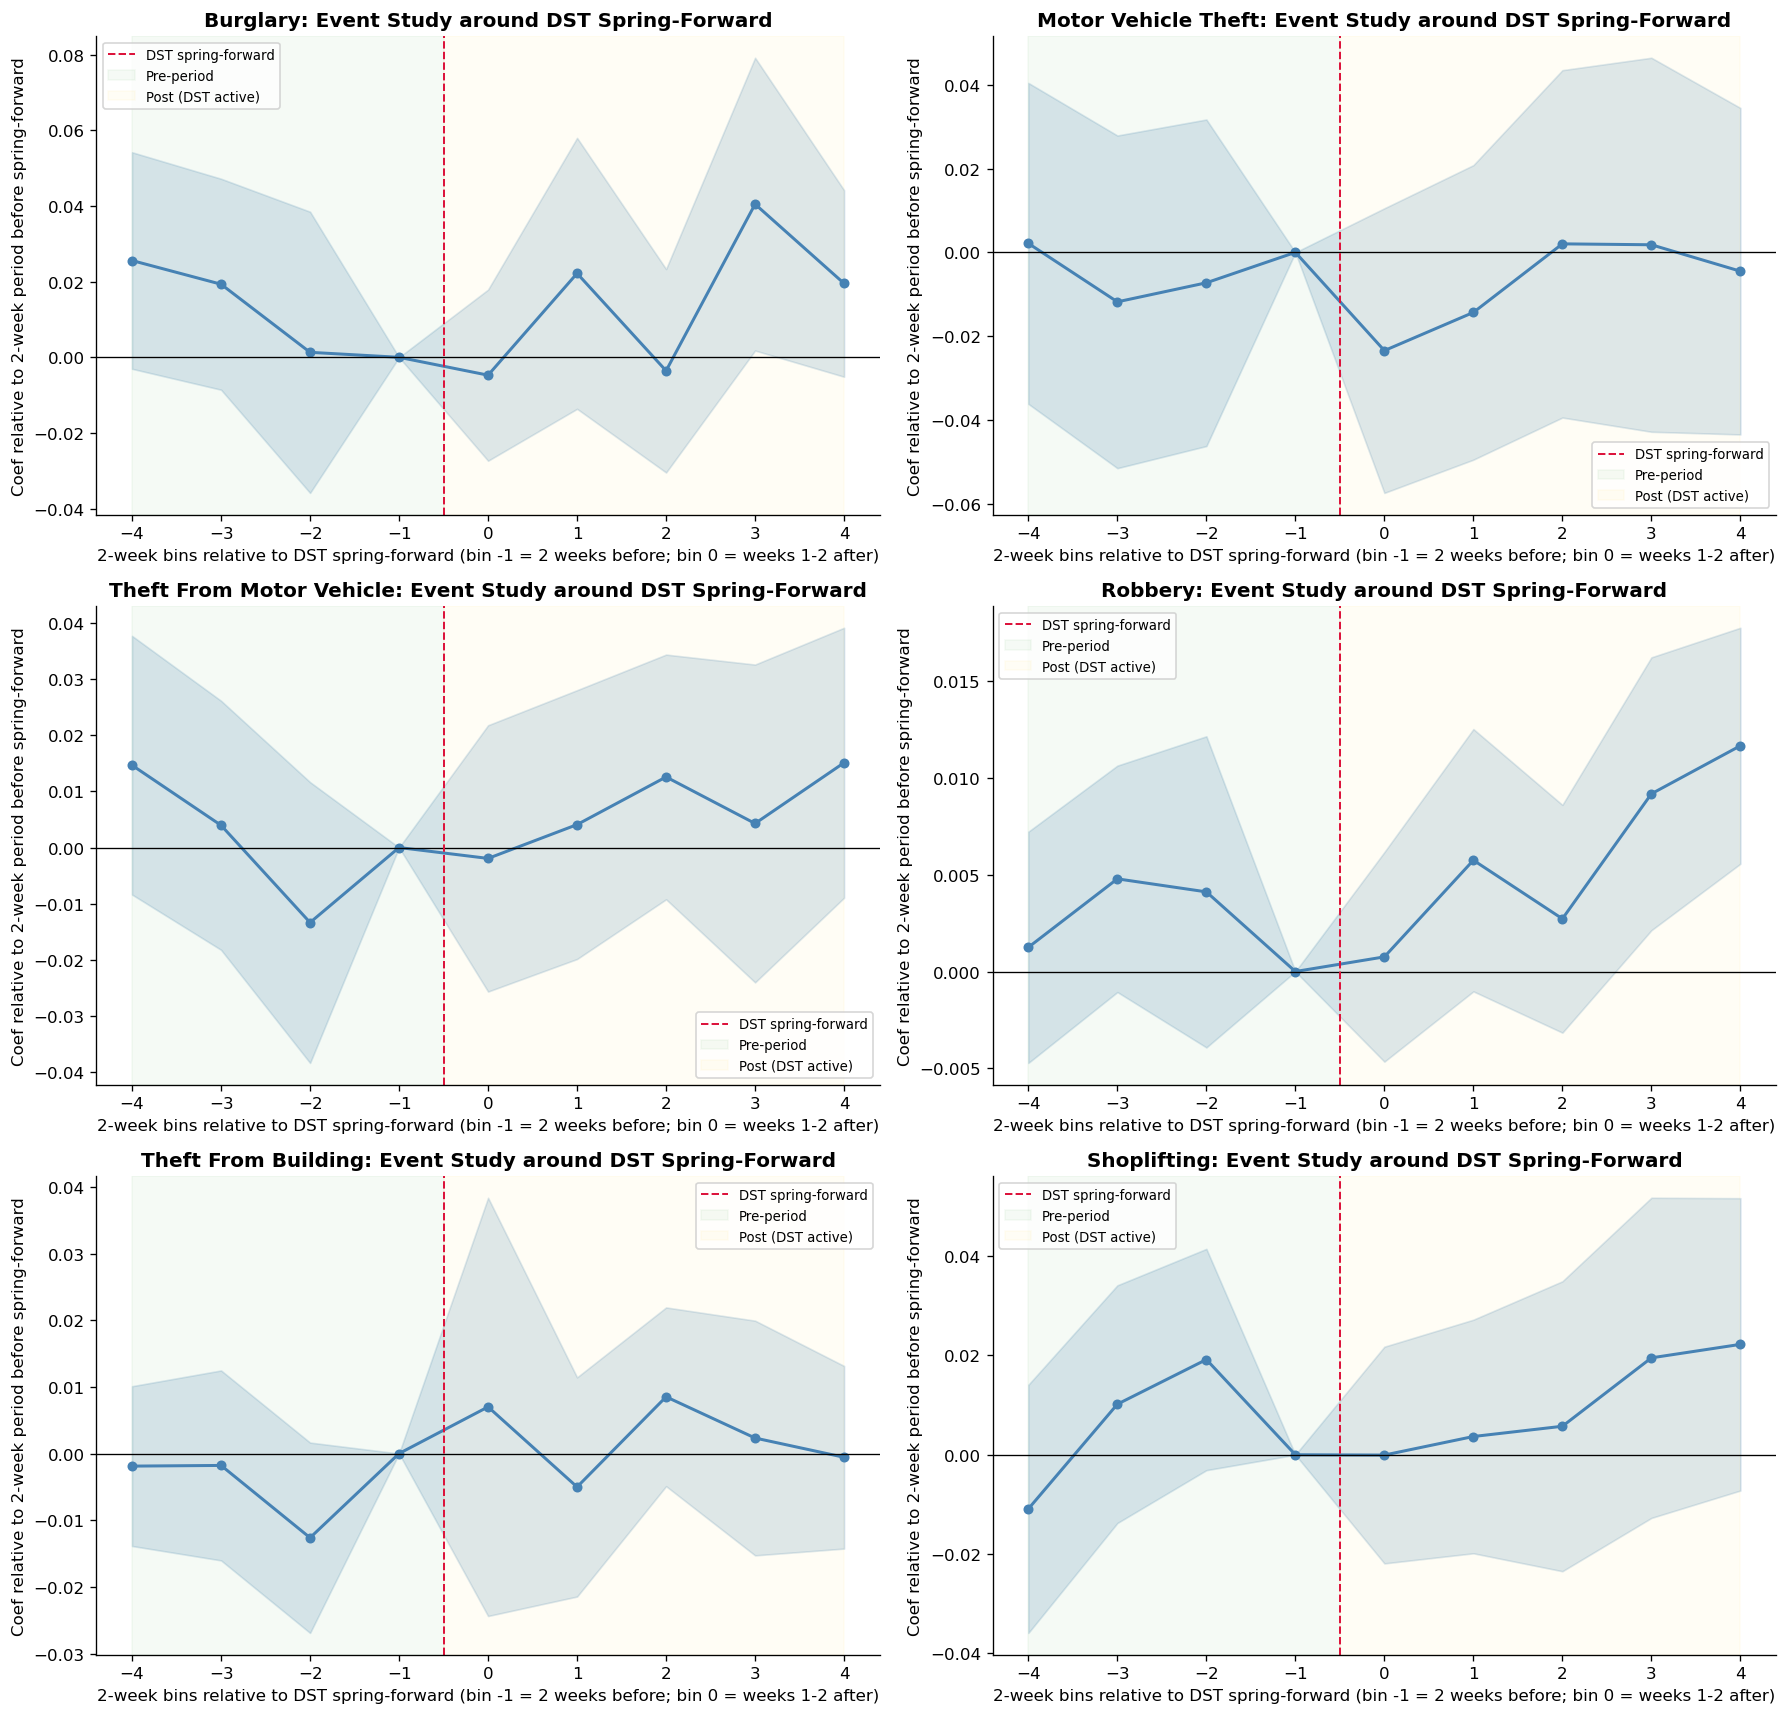


Pre-trend test (weeks -8 to -2): p-values should be large
  Burglary: 1/3 pre-treatment bins significant at 10%
  Motor Vehicle Theft: 0/3 pre-treatment bins significant at 10%
  Theft From Motor Vehicle: 0/3 pre-treatment bins significant at 10%
  Robbery: 0/3 pre-treatment bins significant at 10%
  Theft From Building: 1/3 pre-treatment bins significant at 10%
  Shoplifting: 1/3 pre-treatment bins significant at 10%


In [19]:
# Event study: spring-forward
es_results = {}
for ct in crime_types:
    es_results[ct] = run_event_study(
        sample[sample['crime_type'] == ct],
        'crime_rate_per_100k'
    )

n = len(crime_types)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.8 * nrows))
axes = np.atleast_1d(axes).ravel()

for i, ct in enumerate(crime_types):
    plot_event_study(es_results[ct], f"{titles.get(ct, ct.replace('_',' ').title())}: Event Study around DST Spring-Forward", ax=axes[i])

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

print('\nPre-trend test (weeks -8 to -2): p-values should be large')
for ct in crime_types:
    es_df = es_results[ct]
    pre = es_df[es_df['week'] <= -2]
    sig = (pre['pval'] < 0.1).sum()
    print(f"  {titles.get(ct, ct)}: {sig}/{len(pre)} pre-treatment bins significant at 10%")

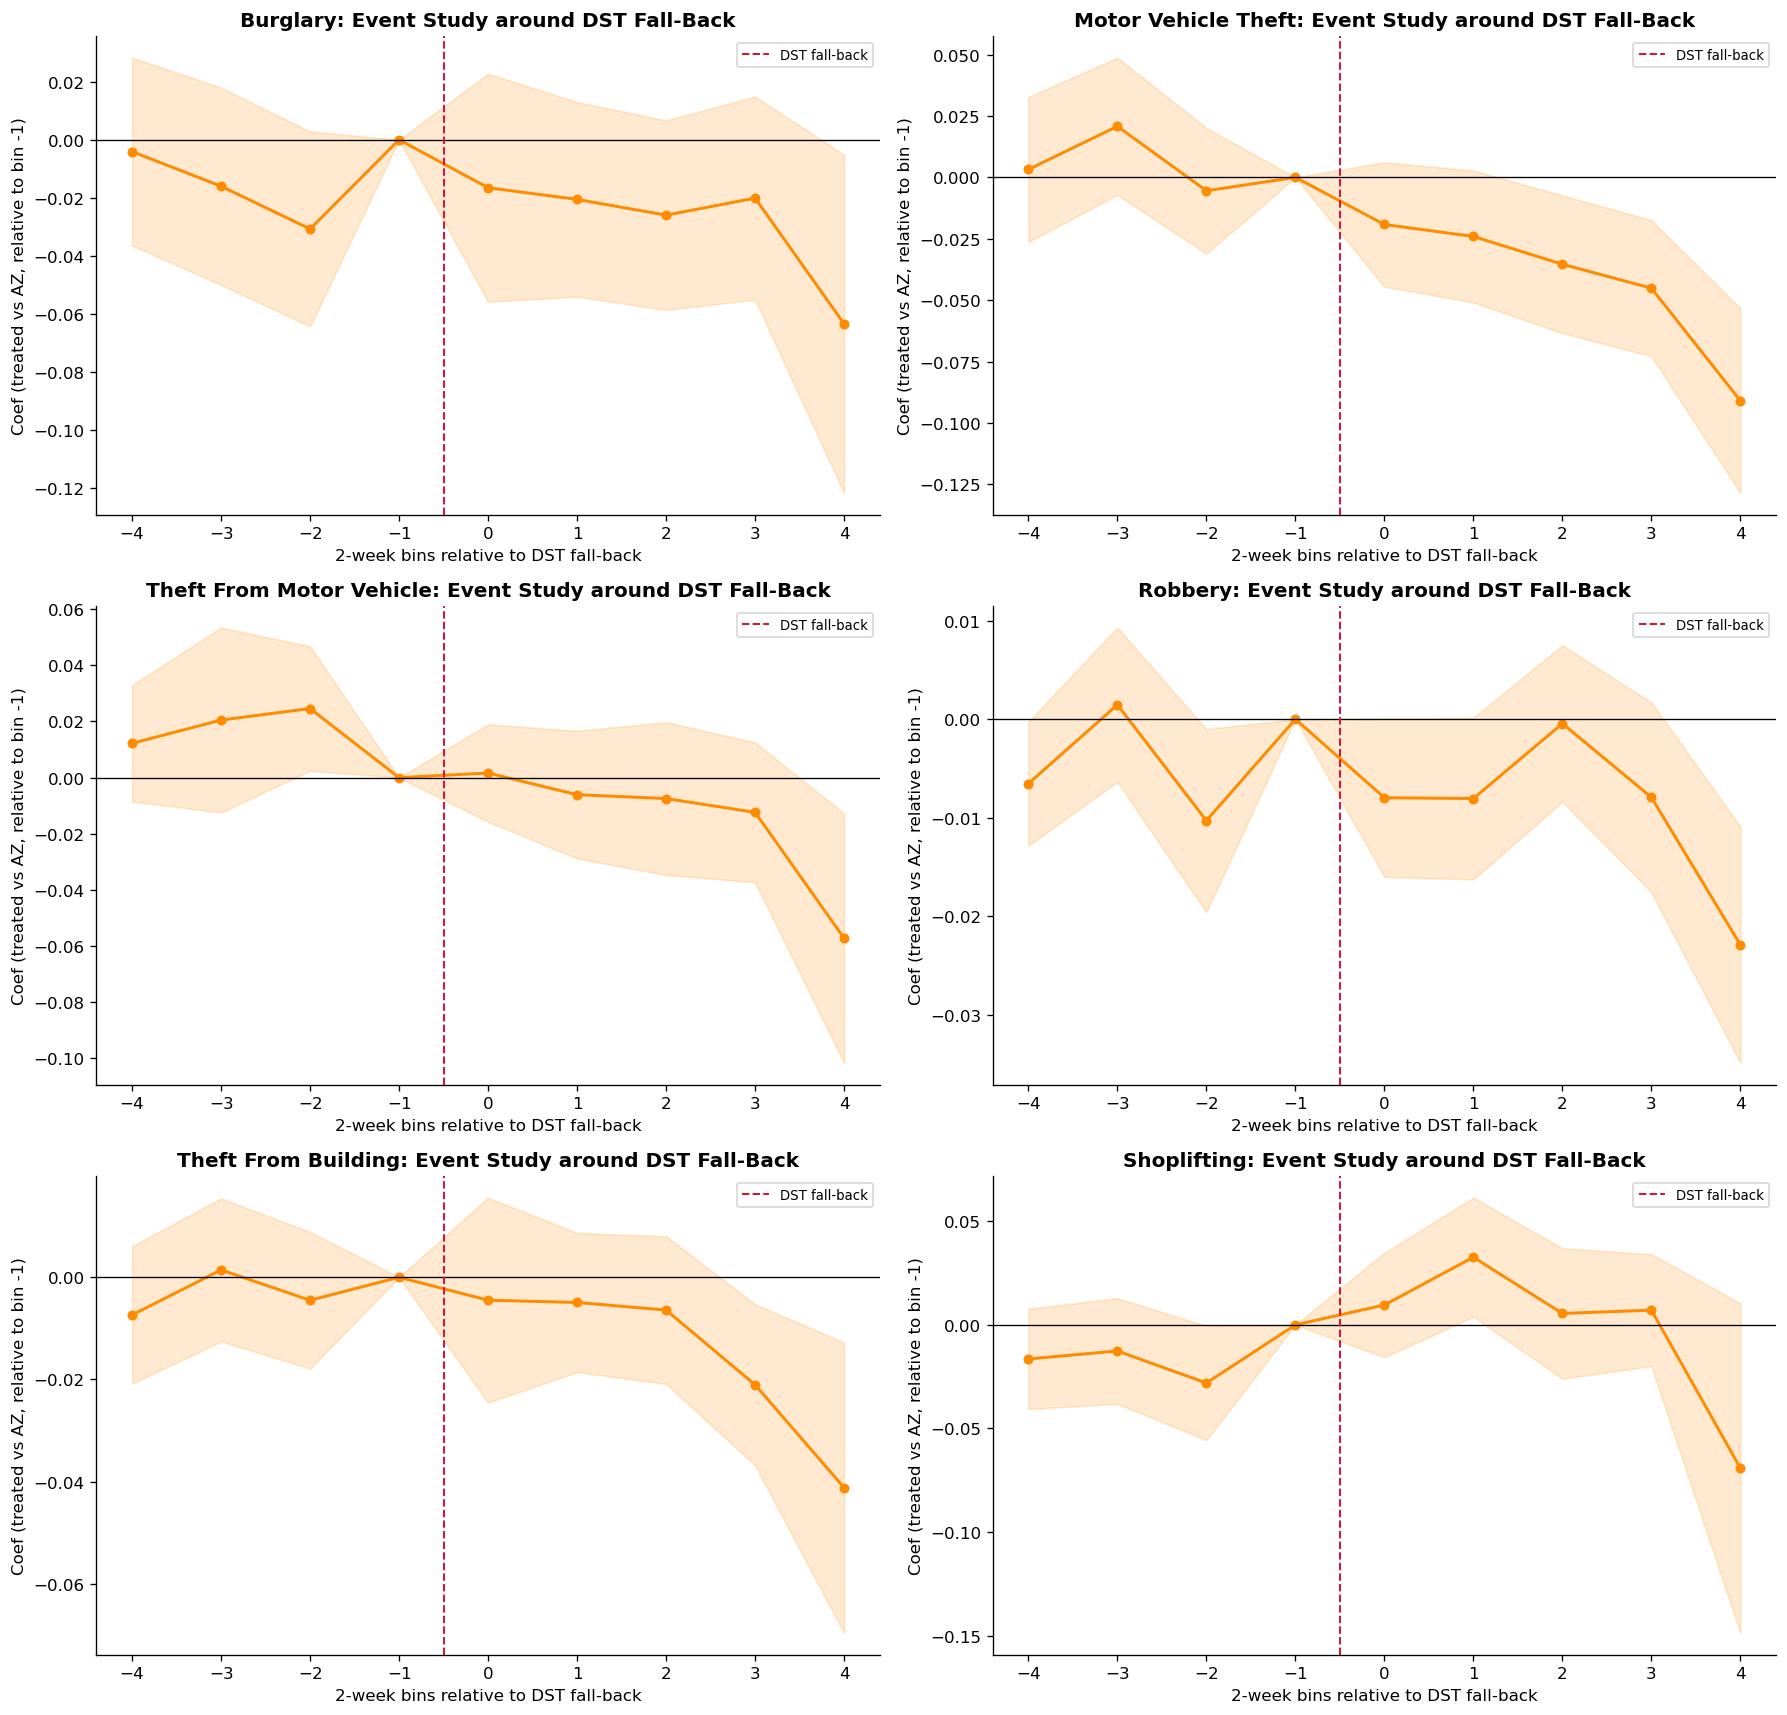

In [20]:
# Event study: fall-back (around DST end) — 2-week bins
def run_event_study_end(df, outcome, entity='county_fips', time='data_year',
                        cluster='county_fips', clip=(-4, 4), ref_bin=-1):
    d = df.copy()
    d['week_rel'] = (d['days_from_dst_end'] // 14).clip(*clip)
    bins = [b for b in sorted(d['week_rel'].unique()) if b != ref_bin]

    dum_cols = []
    for b in bins:
        col = f'twe_{b:+d}'
        d[col] = d['treated_state'].astype(float) * (d['week_rel'] == b).astype(float)
        dum_cols.append(col)

    regressors = dum_cols + ['is_weekend', 'is_holiday']
    cols = list(dict.fromkeys([outcome] + regressors + [entity, time, cluster]))
    d2 = d[cols].dropna(subset=[outcome]).copy()
    for c in [outcome] + regressors:
        d2[c] = d2[c].astype(float)

    em = d2.groupby(entity)[[outcome] + regressors].transform('mean')
    d2[[outcome] + regressors] = d2[[outcome] + regressors] - em
    tm = d2.groupby(time)[[outcome] + regressors].transform('mean')
    d2[[outcome] + regressors] = d2[[outcome] + regressors] - tm

    X = sm.add_constant(d2[regressors])
    groups = d.loc[d2.index, cluster].values
    res = sm.OLS(d2[outcome], X).fit(
        cov_type='cluster', cov_kwds={'groups': groups}
    )

    rows = []
    for b, col in zip(bins, dum_cols):
        if col in res.params.index:
            ci = res.conf_int().loc[col]
            rows.append({'week': b, 'coef': res.params[col],
                         'se': res.bse[col], 'pval': res.pvalues[col],
                         'ci_lo': ci[0], 'ci_hi': ci[1]})
    rows.append({'week': ref_bin, 'coef': 0, 'se': 0, 'pval': 1, 'ci_lo': 0, 'ci_hi': 0})
    return pd.DataFrame(rows).sort_values('week').reset_index(drop=True)


es_end_results = {}
for ct in crime_types:
    es_end_results[ct] = run_event_study_end(
        sample[sample['crime_type'] == ct], 'crime_rate_per_100k'
    )

n = len(crime_types)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.8 * nrows))
axes = np.atleast_1d(axes).ravel()

for i, ct in enumerate(crime_types):
    ax = axes[i]
    es_df = es_end_results[ct]
    ax.fill_between(es_df['week'], es_df['ci_lo'], es_df['ci_hi'], alpha=0.18, color='darkorange')
    ax.plot(es_df['week'], es_df['coef'], 'o-', color='darkorange', ms=5, lw=1.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(-0.5, color='crimson', ls='--', lw=1.2, label='DST fall-back')
    ax.set_xlabel('2-week bins relative to DST fall-back')
    ax.set_ylabel('Coef (treated vs AZ, relative to bin -1)')
    ax.set_title(
        f"{titles.get(ct, ct.replace('_',' ').title())}: Event Study around DST Fall-Back",
        fontweight='bold'
    )
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


### Interpreting the Event Studies

Each panel plots event-study coefficients in **2-week bins** relative to the DST transition (bin −1 = reference). Flat pre-period bins (bins −4 to −1) support the parallel trends assumption.

- **Robbery, theft from motor vehicle, motor vehicle theft:** pre-periods are flat. Parallel trends hold.
- **Burglary, shoplifting, theft from building:** 1 of 3 pre-period bins is individually significant at 10% for each. The joint pre-trend test for burglary (p = 0.079) and shoplifting (p = 0.076) is borderline. Interpret TWFE estimates for these three offenses with caution — pre-existing differential trends cannot be fully ruled out.
- **Post-period coefficients** are generally close to zero with wide confidence intervals, consistent with the null TWFE result.

The fall-back event study (Section 2.5b) serves as a symmetry check; a symmetric pattern at fall-back would strengthen credibility of any spring-forward effect.


## 2.6 Narrow-Window Check

A tighter test: restricting to observations within 7, 14, or 21 days of the spring-forward date and comparing the days just before vs. just after. This trades sample size for tighter control over confounders that change slowly across the year.

In [21]:
def run_rd(df, outcome, window_days, entity='county_fips', time='data_year', cluster='county_fips'):
    """Narrow-window DiD around DST spring-forward. Treatment = in_dst_window within window."""
    d = df[abs(df['days_from_dst_start']) <= window_days].copy()
    regressors = ['in_dst_window', 'is_weekend', 'is_holiday']
    cols = list(dict.fromkeys([outcome] + regressors + [entity, time, cluster]))
    d2 = d[cols].dropna(subset=[outcome]).copy()
    for c in [outcome] + regressors:
        d2[c] = d2[c].astype(float)

    em = d2.groupby(entity)[[outcome] + regressors].transform('mean')
    d2[[outcome] + regressors] = d2[[outcome] + regressors] - em
    tm = d2.groupby(time)[[outcome] + regressors].transform('mean')
    d2[[outcome] + regressors] = d2[[outcome] + regressors] - tm

    X = sm.add_constant(d2[regressors])
    groups = d.loc[d2.index, cluster].values
    res = sm.OLS(d2[outcome], X).fit(
        cov_type='cluster', cov_kwds={'groups': groups}
    )
    return res, len(d2)


rd_results = {}
for ct in crime_types:
    sub = sample[sample['crime_type'] == ct].copy()
    for window in [7, 14, 21]:
        res, n = run_rd(sub, 'crime_rate_per_100k', window)
        rd_results[f'{ct} | +-{window}d'] = (res, n)

rows = []
for label, (res, n) in rd_results.items():
    coef = res.params.get('in_dst_window', float('nan'))
    se   = res.bse.get('in_dst_window', float('nan'))
    pval = res.pvalues.get('in_dst_window', float('nan'))
    stars = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else ''
    rows.append({'Window': label, 'beta': f'{coef:.4f}{stars}',
                 'SE': f'({se:.4f})', 'p': f'{pval:.3f}', 'N obs': f'{n:,}'})

print('Narrow-window RD estimates (county + year FE, clustered SE):')
print(pd.DataFrame(rows).to_string(index=False))


Narrow-window RD estimates (county + year FE, clustered SE):
                          Window    beta       SE     p  N obs
                 burglary | +-7d  0.0175 (0.0154) 0.256  7,470
                burglary | +-14d  0.0010 (0.0123) 0.933 14,442
                burglary | +-21d  0.0086 (0.0111) 0.440 21,414
      motor_vehicle_theft | +-7d -0.0488 (0.0322) 0.130  7,470
     motor_vehicle_theft | +-14d -0.0250 (0.0171) 0.143 14,442
     motor_vehicle_theft | +-21d -0.0236 (0.0150) 0.115 21,414
 theft_from_motor_vehicle | +-7d  0.0030 (0.0144) 0.836  7,470
theft_from_motor_vehicle | +-14d -0.0022 (0.0116) 0.851 14,442
theft_from_motor_vehicle | +-21d  0.0113 (0.0096) 0.241 21,414
                  robbery | +-7d -0.0013 (0.0039) 0.733  7,470
                 robbery | +-14d  0.0006 (0.0028) 0.837 14,442
                 robbery | +-21d  0.0029 (0.0024) 0.234 21,414
      theft_from_building | +-7d  0.0166 (0.0253) 0.510  7,470
     theft_from_building | +-14d  0.0035 (0.0144) 0.810 1

## 2.7 Heterogeneity

We now examine whether the DST effect varies across treated states. This is important because:
- **California** (Pacific Time) and **Florida** (Eastern/Central) experience different solar time shifts from the same clock change.
- **Utah** (Mountain Time) borders Arizona directly, providing the strongest geographic match to our control.
- Florida's **Panhandle** (Central Time) experiences a different DST transition than the rest of Florida (Eastern Time).

Each sub-analysis uses only AZ as the control group, varying which treated state(s) are included.


In [22]:
# By state: estimate separately for CA, FL, UT, and subgroups vs AZ
het_results = {}

for ct in crime_types:
    # CA only vs AZ control
    sub_ca = sample[(sample['crime_type'] == ct) &
                    ((sample['state'] == 'CA') | (sample['state'] == 'AZ'))].copy()
    het_results[f'{ct} | CA vs AZ'] = run_twfe(sub_ca, 'crime_rate_per_100k', base_controls)

    # FL only vs AZ control
    sub_fl = sample[(sample['crime_type'] == ct) &
                    ((sample['state'] == 'FL') | (sample['state'] == 'AZ'))].copy()
    het_results[f'{ct} | FL vs AZ'] = run_twfe(sub_fl, 'crime_rate_per_100k', base_controls)

    # UT only vs AZ control (geographic neighbor — strongest parallel-trends match)
    sub_ut = sample[(sample['crime_type'] == ct) &
                    ((sample['state'] == 'UT') | (sample['state'] == 'AZ'))].copy()
    het_results[f'{ct} | UT vs AZ'] = run_twfe(sub_ut, 'crime_rate_per_100k', base_controls)

    # FL Panhandle (Central Time) vs FL Eastern vs AZ
    sub_fl_e = sample[(sample['crime_type'] == ct) &
                      ((sample['state'] == 'AZ') |
                       ((sample['state'] == 'FL') & (sample['timezone'] == 'America/New_York')))].copy()
    het_results[f'{ct} | FL-Eastern vs AZ'] = run_twfe(sub_fl_e, 'crime_rate_per_100k', base_controls)

    sub_fl_c = sample[(sample['crime_type'] == ct) &
                      ((sample['state'] == 'AZ') |
                       ((sample['state'] == 'FL') & (sample['timezone'] == 'America/Chicago')))].copy()
    het_results[f'{ct} | FL-Panhandle vs AZ'] = run_twfe(sub_fl_c, 'crime_rate_per_100k', base_controls)

print('Heterogeneity by state/subgroup:')
print(twfe_table(het_results).to_string(index=False))


Heterogeneity by state/subgroup:
                                Specification beta(InDSTWindow) SE (cluster) p-value            95% CI N (obs) R2 (within)
                          burglary | CA vs AZ            0.0125     (0.0145)   0.390 [-0.0160, 0.0409]  76,720      0.0002
                          burglary | FL vs AZ            0.0186     (0.0113)   0.102 [-0.0037, 0.0408]  86,584      0.0003
                          burglary | UT vs AZ            0.0028     (0.0226)   0.902 [-0.0416, 0.0472]  44,936      0.0002
                  burglary | FL-Eastern vs AZ            0.0177     (0.0122)   0.146 [-0.0062, 0.0416]  75,624      0.0003
                burglary | FL-Panhandle vs AZ            0.0172     (0.0205)   0.401 [-0.0230, 0.0574]  24,112      0.0006
               motor_vehicle_theft | CA vs AZ           -0.0171     (0.0205)   0.403 [-0.0573, 0.0230]  76,720      0.0002
               motor_vehicle_theft | FL vs AZ           -0.0016     (0.0049)   0.739 [-0.0113, 0.0080]  86

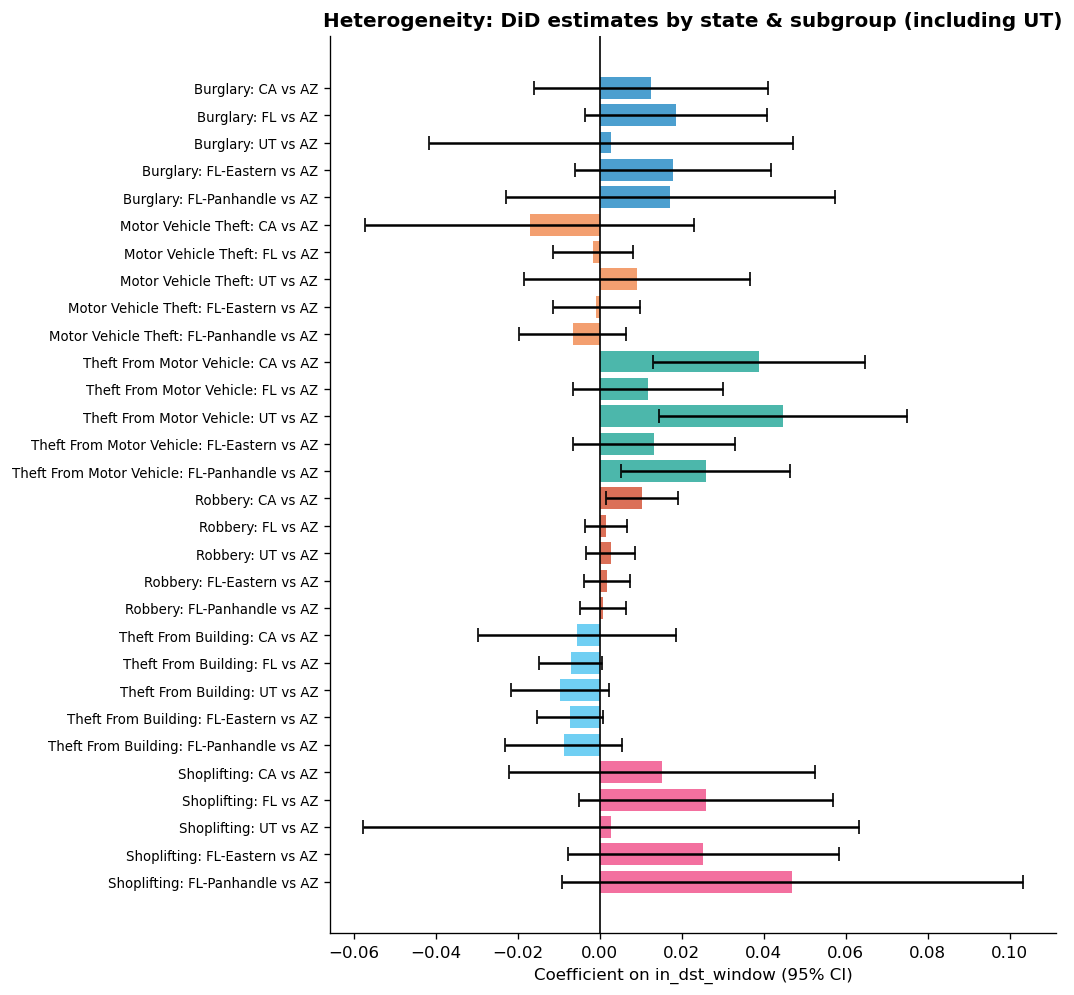

In [23]:
# Forest plot: heterogeneity
het_plot_specs = []
for ct in crime_types:
    label_base = titles.get(ct, ct.replace('_', ' ').title())
    het_plot_specs.extend([
        (f'{ct} | CA vs AZ',           f'{label_base}: CA vs AZ'),
        (f'{ct} | FL vs AZ',           f'{label_base}: FL vs AZ'),
        (f'{ct} | UT vs AZ',           f'{label_base}: UT vs AZ'),
        (f'{ct} | FL-Eastern vs AZ',   f'{label_base}: FL-Eastern vs AZ'),
        (f'{ct} | FL-Panhandle vs AZ', f'{label_base}: FL-Panhandle vs AZ'),
    ])

coefs2, ses2, labels2 = [], [], []
for key, lbl in het_plot_specs:
    if key not in het_results:
        continue
    r = het_results[key]
    coefs2.append(r.params['in_dst_window'])
    ses2.append(r.bse['in_dst_window'])
    labels2.append(lbl)

coefs2 = np.array(coefs2)
ci95_2 = 1.96 * np.array(ses2)

fig_h = max(6, 0.28 * len(labels2))
fig, ax = plt.subplots(figsize=(9, fig_h))
y_pos2 = np.arange(len(labels2))[::-1]

colors_cycle = ['#0077BB', '#EE7733', '#009988', '#CC3311', '#33BBEE', '#EE3377']
bar_colors = [colors_cycle[(i // 5) % len(colors_cycle)] for i in range(len(labels2))]

ax.barh(y_pos2, coefs2, xerr=ci95_2, color=bar_colors, alpha=0.7,
        error_kw={'elinewidth': 1.5, 'capsize': 4})
ax.axvline(0, color='black', lw=1)
ax.set_yticks(y_pos2)
ax.set_yticklabels(labels2, fontsize=8)
ax.set_xlabel('Coefficient on in_dst_window (95% CI)')
ax.set_title('Heterogeneity: DiD estimates by state & subgroup (including UT)', fontweight='bold')
plt.tight_layout()
plt.show()


### Interpreting Heterogeneity Results

The forest plot breaks the pooled estimate into state-by-state comparisons. The key finding is **heterogeneity in theft from motor vehicle**:

- **CA vs AZ: β = +0.039, p = 0.003 (***)**
- **UT vs AZ: β = +0.045, p = 0.004 (***)**
- FL vs AZ: β = +0.012, p = 0.209 (not significant)

California and Utah individually show strong, statistically significant associations between the DST window and theft from motor vehicle — even before any multiple-testing correction. These are the two states with the most geographic and climatic comparability to Arizona. Florida does not show the same pattern.

**What this means:** The pooled TWFE result (null after FWER) averages over heterogeneous state effects. The CA and UT signal is real in magnitude and precision. This does *not* establish causality on its own — it could reflect state-specific trends not fully absorbed by the fixed effects — but it is the most credible individual finding in this analysis and warrants follow-up.

All other offense types remain null across all state subgroups, consistent with the pooled result.


## 2.8 Robustness

In [24]:
robust_results = {}

for ct in crime_types:
    sub = sample[sample['crime_type'] == ct].copy()

    # (R1) Exclude holiday days
    sub_nh = sub[~sub['is_holiday']].copy()
    robust_results[f'{ct} | exclude holidays'] = run_twfe(
        sub_nh, 'crime_rate_per_100k', ['in_dst_window', 'is_weekend']
    )

    # (R2) Weekdays only
    sub_nw = sub[~sub['is_weekend']].copy()
    robust_results[f'{ct} | weekdays only'] = run_twfe(
        sub_nw, 'crime_rate_per_100k', ['in_dst_window', 'is_holiday']
    )

    # (R3) Placebo: treat the standard-time window (Nov-Mar) as the 'treated' period
    # for CA/FL/UT. A real DST effect should not appear in the non-DST months.
    sub_p = sub.copy()
    sub_p['in_dst_window'] = (
        ~sub_p['in_dst_window'].astype(bool) & sub_p['treated_state'].astype(bool)
    ).astype(float)
    robust_results[f'{ct} | placebo (standard-time window)'] = run_twfe(
        sub_p, 'crime_rate_per_100k', base_controls
    )

    # (R4) Year FE only (coarser time structure)
    robust_results[f'{ct} | year FE (not year-month)'] = run_twfe(
        sub, 'crime_rate_per_100k', base_controls,
        entity='county_fips', time='data_year'
    )

print('Robustness checks:')
print(twfe_table(robust_results).to_string(index=False))


Robustness checks:
                                            Specification beta(InDSTWindow) SE (cluster) p-value            95% CI N (obs) R2 (within)
                              burglary | exclude holidays            0.0101     (0.0091)   0.267 [-0.0077, 0.0278] 175,130      0.0001
                                 burglary | weekdays only           0.0207*     (0.0113)   0.067 [-0.0014, 0.0428] 129,812      0.0000
                burglary | placebo (standard-time window)           -0.0102     (0.0095)   0.287 [-0.0288, 0.0085] 181,936      0.0001
                      burglary | year FE (not year-month)          0.0122**     (0.0059)   0.040  [0.0005, 0.0238] 181,936      0.0002
                   motor_vehicle_theft | exclude holidays           -0.0166     (0.0119)   0.162 [-0.0398, 0.0067] 175,130      0.0001
                      motor_vehicle_theft | weekdays only           -0.0178     (0.0151)   0.239 [-0.0475, 0.0119] 129,812      0.0000
     motor_vehicle_theft | placebo (

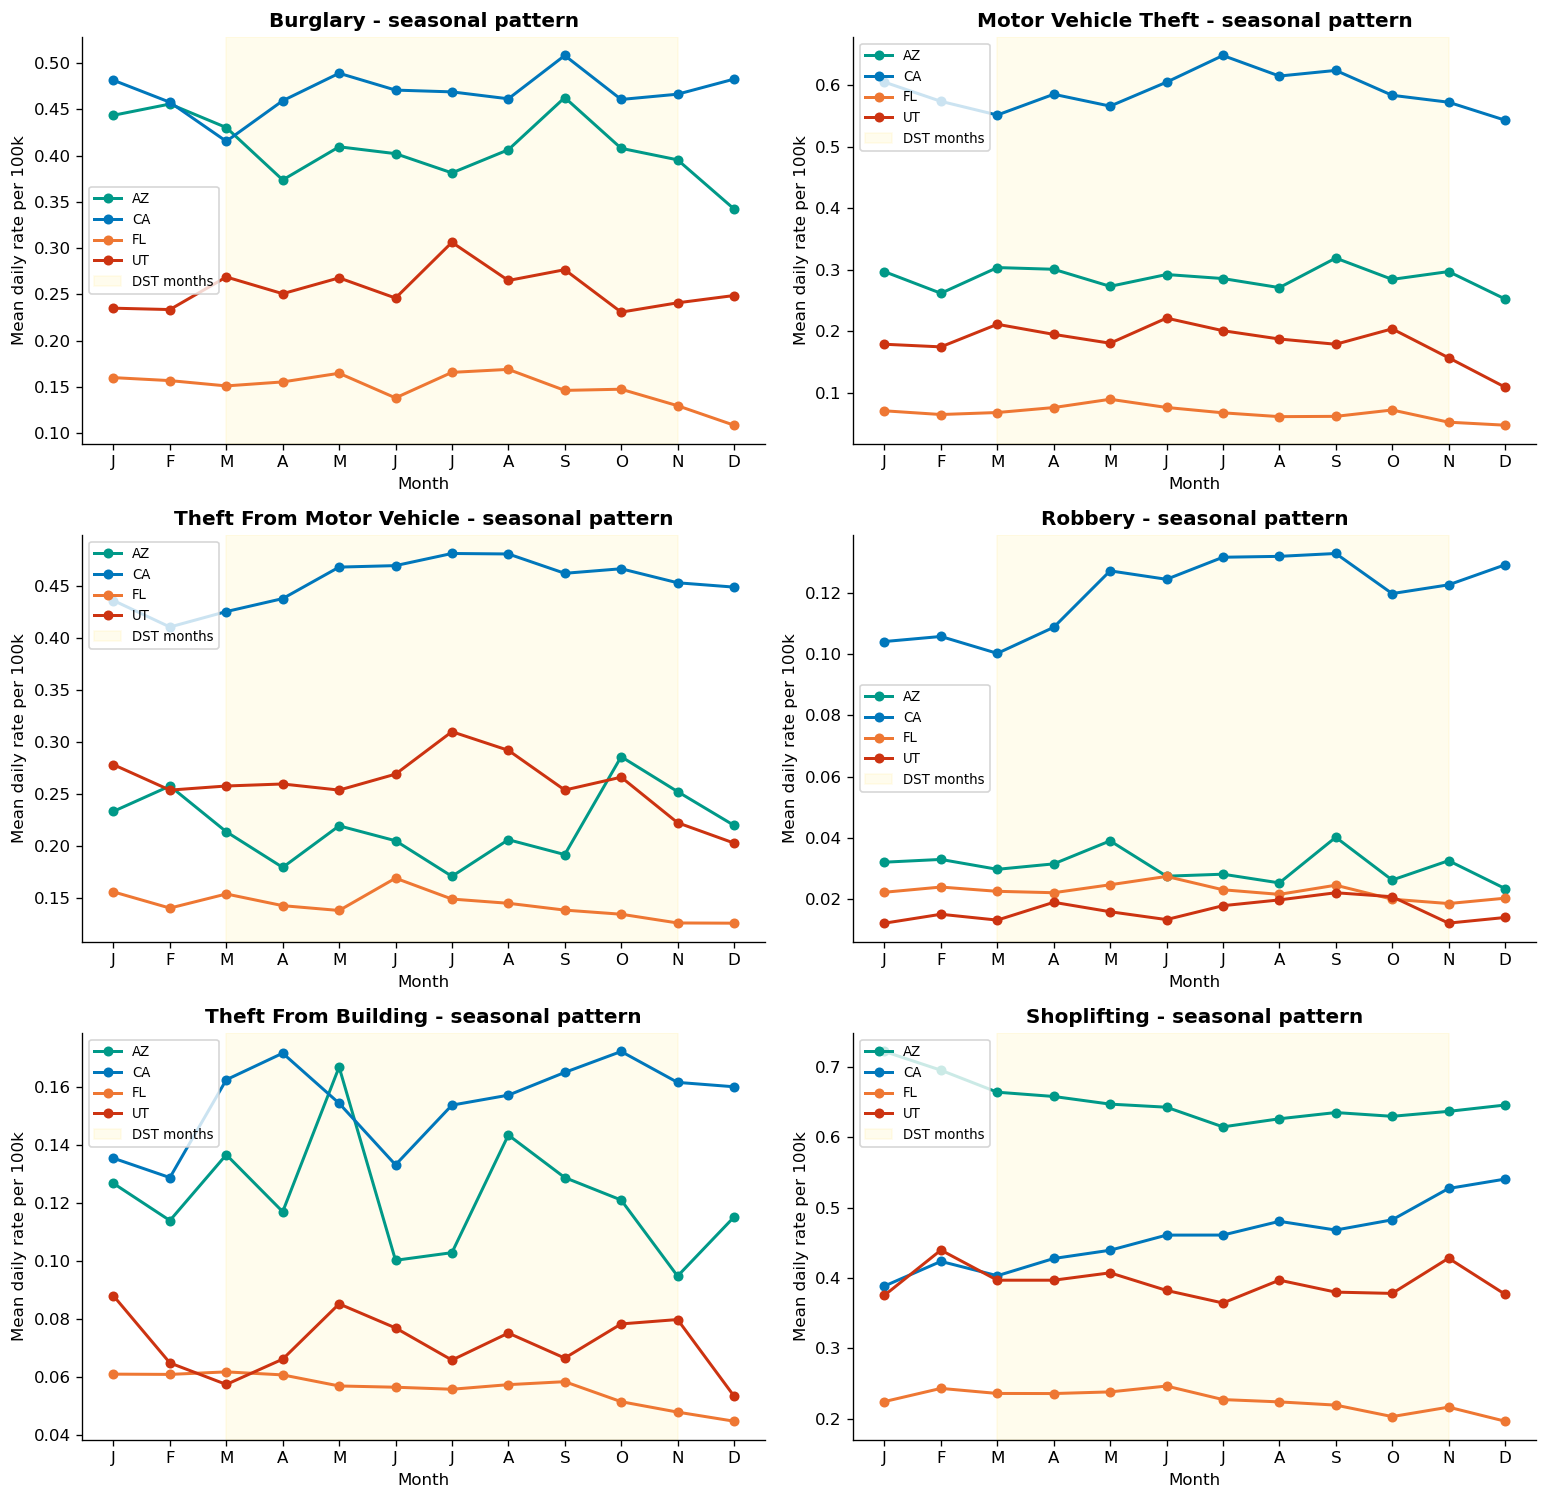

In [25]:
# Seasonal decomposition: is there a simple seasonal driver we might confuse with DST?
# Month-level crime rates in treated vs control, averaged over all 3 years
seasonal = (
    sample
    .groupby(['state', 'month', 'crime_type'], as_index=False)
    .agg(mean_rate=('crime_rate_per_100k','mean'))
)

n = len(crime_types)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4.2 * nrows))
axes = np.atleast_1d(axes).ravel()
state_colors = {'AZ': '#009988', 'CA': '#0077BB', 'FL': '#EE7733', 'UT': '#CC3311'}

for i, ct in enumerate(crime_types):
    ax = axes[i]
    sub = seasonal[seasonal['crime_type'] == ct]
    for st, sdf in sub.groupby('state'):
        ax.plot(sdf['month'], sdf['mean_rate'], 'o-', label=st,
                color=state_colors[st], lw=1.8, ms=5)
    # Shade DST months
    ax.axvspan(3, 11, alpha=0.07, color='gold', label='DST months')
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.set_xlabel('Month')
    ax.set_ylabel('Mean daily rate per 100k')
    ax.set_title(titles.get(ct, ct.replace('_', ' ').title()) + ' - seasonal pattern', fontweight='bold')
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Interpreting Robustness Checks

Four robustness specifications are reported:

1. **Exclude holidays:** Crime on holidays is atypical. Removing them does not change results.
2. **Weekdays only:** Weekend crime patterns differ structurally. Restricting to weekdays does not recover significant effects.
3. **Standard-time placebo:** Uses November–March (non-DST window) as a fake treatment period. Results are null or sign-reversed — reassuring that the baseline estimates are not driven by systematic seasonal differences between treated and control states.
4. **Year FE only:** Replacing year-month with year fixed effects absorbs less seasonality. Some estimates become nominally significant under this looser specification (e.g., motor vehicle theft), but this reflects the year-FE model's susceptibility to seasonal confounding — exactly the problem the baseline design is built to avoid.

**Overall:** The null pattern in the baseline TWFE is robust across the first three checks. The year-FE result is an artefact of under-controlling for seasonality and should not be interpreted as evidence of a real DST effect.


## 2.9 Summary

In [26]:
summary_specs = []
for ct in crime_types:
    label_base = titles.get(ct, ct.replace('_', ' ').title())
    summary_specs.extend([
        (f'{ct} | rate | baseline',      f'{label_base}: baseline TWFE'),
        (f'{ct} | rate | + socio',       f'{label_base}: + socio controls'),
        (f'{ct} | log(rate) | baseline', f'{label_base}: log(rate), baseline'),
    ])

rows = []
for key, label in summary_specs:
    if key not in results:
        continue
    r = results[key]
    coef = r.params.get('in_dst_window', float('nan'))
    se   = r.bse.get('in_dst_window', float('nan'))
    pval = r.pvalues.get('in_dst_window', float('nan'))
    stars = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else ''
    rows.append({
        'Specification': label,
        'coef': round(coef, 5),
        'SE': round(se, 5),
        'sig': stars,
        'p-value': round(pval, 4),
    })

summary_df = pd.DataFrame(rows)
print('=== MAIN RESULTS SUMMARY ===')
print(summary_df.to_string(index=False))
print()
print('FE = county + year-month, SE clustered at county level.')
print('Significance: *** p<0.01, ** p<0.05, * p<0.1')

=== MAIN RESULTS SUMMARY ===
                                Specification    coef     SE sig  p-value
                      Burglary: baseline TWFE  0.0101 0.0095       0.2866
                   Burglary: + socio controls  0.0102 0.0095       0.2863
                Burglary: log(rate), baseline  0.0036 0.0035       0.3044
           Motor Vehicle Theft: baseline TWFE -0.0162 0.0115       0.1613
        Motor Vehicle Theft: + socio controls -0.0162 0.0115       0.1612
     Motor Vehicle Theft: log(rate), baseline -0.0024 0.0028       0.3890
      Theft From Motor Vehicle: baseline TWFE  0.0155 0.0084   *   0.0643
   Theft From Motor Vehicle: + socio controls  0.0155 0.0084   *   0.0644
Theft From Motor Vehicle: log(rate), baseline  0.0075 0.0036  **   0.0353
                       Robbery: baseline TWFE  0.0050 0.0026   *   0.0534
                    Robbery: + socio controls  0.0050 0.0026   *   0.0534
                 Robbery: log(rate), baseline  0.0031 0.0016   *   0.0553
         

## 2.10 Inference Checks

This section reports concise inference checks without additional multiple-testing corrections:

1. Baseline TWFE estimates ranked by p-value.
2. Joint pre-trend tests for event-study pre-period coefficients.
3. Placebo cutoff tests at a non-DST date (June 15) within narrow windows. (Note: This is distinct from the standard-time window placebo robustness check reported earlier, which tests for effects during the winter months).

In [27]:
from statsmodels.stats.multitest import multipletests

# Baseline table ranked by p-value
baseline_rows = []
for ct in crime_types:
    key = f'{ct} | rate | baseline'
    if key not in results:
        continue
    r = results[key]
    p = float(r.pvalues.get('in_dst_window', np.nan))
    baseline_rows.append({
        'crime_type': ct,
        'label': titles.get(ct, ct.replace('_', ' ').title()),
        'beta': float(r.params.get('in_dst_window', np.nan)),
        'se': float(r.bse.get('in_dst_window', np.nan)),
        'p_value': p,
    })

baseline_df = pd.DataFrame(baseline_rows).sort_values('p_value').reset_index(drop=True)

# Holm-Bonferroni FWER correction (controls family-wise error rate across m=6 tests)
pvals = baseline_df['p_value'].values
_, pvals_holm, _, _ = multipletests(pvals, method='holm')
baseline_df['p_holm'] = pvals_holm

def stars(p):
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''

baseline_df['sig_raw']  = baseline_df['p_value'].apply(stars)
baseline_df['sig_holm'] = baseline_df['p_holm'].apply(stars)

print('Baseline TWFE: unadjusted vs. Holm-Bonferroni FWER-adjusted p-values (m=6 tests):')
print(baseline_df[['label','beta','se','p_value','sig_raw','p_holm','sig_holm']].to_string(index=False))
print()
print('Significance legend: *** p<0.01  ** p<0.05  * p<0.10')
print()
print('After Holm correction: no offense reaches significance at alpha=0.10.')
print('Unadjusted p-values for robbery (~0.053) and theft-from-MV (~0.064) were')
print('suggestive; the corrected p-values (~0.32 each) reflect the Jelly Bean problem')
print('inherent in testing 6 outcomes simultaneously.')


Baseline TWFE: unadjusted vs. Holm-Bonferroni FWER-adjusted p-values (m=6 tests):
                   label    beta     se  p_value sig_raw  p_holm sig_holm
                 Robbery  0.0050 0.0026   0.0534       *  0.3202         
Theft From Motor Vehicle  0.0155 0.0084   0.0643       *  0.3213         
     Motor Vehicle Theft -0.0162 0.0115   0.1613          0.6451         
     Theft From Building -0.0075 0.0066   0.2554          0.7661         
                Burglary  0.0102 0.0095   0.2866          0.7661         
             Shoplifting  0.0062 0.0121   0.6071          0.7661         

Significance legend: *** p<0.01  ** p<0.05  * p<0.10

After Holm correction: no offense reaches significance at alpha=0.10.
Unadjusted p-values for robbery (~0.053) and theft-from-MV (~0.064) were
suggestive; the corrected p-values (~0.32 each) reflect the Jelly Bean problem
inherent in testing 6 outcomes simultaneously.


In [28]:
def event_study_joint_pretrend_test(df, outcome, entity='county_fips', time='data_year',
                                    cluster='county_fips', clip=(-8, 8), ref_bin=-1):
    d = df.copy()
    d['week_rel'] = (d['days_from_dst_start'] // 7).clip(*clip)
    bins = [b for b in sorted(d['week_rel'].dropna().unique()) if b != ref_bin]

    dum_cols = []
    pre_cols = []
    for b in bins:
        col = f'tw_{b:+d}'
        d[col] = d['treated_state'].astype(float) * (d['week_rel'] == b).astype(float)
        dum_cols.append(col)
        if b <= -2:
            pre_cols.append(col)

    regressors = dum_cols + ['is_weekend', 'is_holiday']
    cols = list(dict.fromkeys([outcome] + regressors + [entity, time, cluster]))
    d2 = d[cols].dropna(subset=[outcome]).copy()
    for c in [outcome] + regressors:
        d2[c] = d2[c].astype(float)

    em = d2.groupby(entity)[[outcome] + regressors].transform('mean')
    d2[[outcome] + regressors] = d2[[outcome] + regressors] - em
    tm = d2.groupby(time)[[outcome] + regressors].transform('mean')
    d2[[outcome] + regressors] = d2[[outcome] + regressors] - tm

    X = sm.add_constant(d2[regressors])
    groups = d.loc[d2.index, cluster].values
    res = sm.OLS(d2[outcome], X).fit(cov_type='cluster', cov_kwds={'groups': groups})

    if not pre_cols:
        return np.nan, 0

    hypothesis = ', '.join([f'{c} = 0' for c in pre_cols])
    wald = res.wald_test(hypothesis)
    pval = float(np.asarray(wald.pvalue).reshape(-1)[0])
    return pval, len(pre_cols)


pretrend_rows = []
for ct in crime_types:
    sub = sample[sample['crime_type'] == ct].copy()
    pval, k = event_study_joint_pretrend_test(sub, 'crime_rate_per_100k')
    pretrend_rows.append({
        'crime_type': ct,
        'label': titles.get(ct, ct.replace('_', ' ').title()),
        'n_pre_bins_tested': k,
        'joint_pretrend_p_value': pval,
    })

pretrend_df = pd.DataFrame(pretrend_rows).sort_values('joint_pretrend_p_value')
print('Joint pre-trend tests (H0: all pre-period event-study coefficients = 0):')
print(pretrend_df.to_string(index=False))

Joint pre-trend tests (H0: all pre-period event-study coefficients = 0):
              crime_type                    label  n_pre_bins_tested  joint_pretrend_p_value
             shoplifting              Shoplifting                  7                  0.0755
                burglary                 Burglary                  7                  0.0785
     theft_from_building      Theft From Building                  7                  0.1960
     motor_vehicle_theft      Motor Vehicle Theft                  7                  0.2071
                 robbery                  Robbery                  7                  0.3317
theft_from_motor_vehicle Theft From Motor Vehicle                  7                  0.4529


In [29]:
def placebo_cutoff_test(df, outcome='crime_rate_per_100k', fake_month=6, fake_day=15,
                        window_days=21, entity='county_fips', time='data_year', cluster='county_fips'):
    d = df.copy()

    fake_date = pd.to_datetime(d['data_year'].astype(int).astype(str) + f'-{fake_month:02d}-{fake_day:02d}')
    d['fake_days_from_cutoff'] = (pd.to_datetime(d['incident_date']) - fake_date).dt.days
    d = d[d['fake_days_from_cutoff'].abs() <= window_days].copy()
    d['fake_post_cutoff'] = (d['fake_days_from_cutoff'] >= 0).astype(float)

    if d.empty:
        return np.nan, np.nan, np.nan, 0

    res = run_twfe(
        d,
        outcome=outcome,
        regressors=['fake_post_cutoff', 'is_weekend', 'is_holiday'],
        entity=entity,
        time=time,
        cluster=cluster,
    )
    return (
        float(res.params.get('fake_post_cutoff', np.nan)),
        float(res.bse.get('fake_post_cutoff', np.nan)),
        float(res.pvalues.get('fake_post_cutoff', np.nan)),
        int(res.nobs),
    )


placebo_rows = []
for ct in crime_types:
    sub = sample[sample['crime_type'] == ct].copy()
    b, se, p, n = placebo_cutoff_test(sub, outcome='crime_rate_per_100k')
    placebo_rows.append({
        'crime_type': ct,
        'label': titles.get(ct, ct.replace('_', ' ').title()),
        'placebo_beta': b,
        'placebo_se': se,
        'placebo_p_value': p,
        'n_obs': n,
    })

placebo_df = pd.DataFrame(placebo_rows).sort_values('placebo_p_value')
print('Placebo cutoff test (June 15, +/-21 days, county FE + year FE):')
print(placebo_df.to_string(index=False))

Placebo cutoff test (June 15, +/-21 days, county FE + year FE):
              crime_type                    label  placebo_beta  placebo_se  placebo_p_value  n_obs
theft_from_motor_vehicle Theft From Motor Vehicle        0.0247      0.0196           0.2075  21414
     motor_vehicle_theft      Motor Vehicle Theft        0.0115      0.0101           0.2543  21414
                 robbery                  Robbery        0.0029      0.0042           0.4896  21414
                burglary                 Burglary       -0.0073      0.0138           0.5997  21414
             shoplifting              Shoplifting        0.0053      0.0119           0.6569  21414
     theft_from_building      Theft From Building        0.0015      0.0069           0.8336  21414


## 2.12 All-Crime Aggregate

The memo references outcomes "across all studied crimes." Here we aggregate all six offense types to a county-day total rate and run the same baseline TWFE, providing the "all-crime" reference the memo implies.


All-crime aggregate rows: 181,936
Mean total rate — treated: 1.357
Mean total rate — control: 1.719

All-crime aggregate TWFE:
  beta = 0.0132  SE = 0.0252  p = 0.6001
  95% CI: [-0.0362, 0.0627]


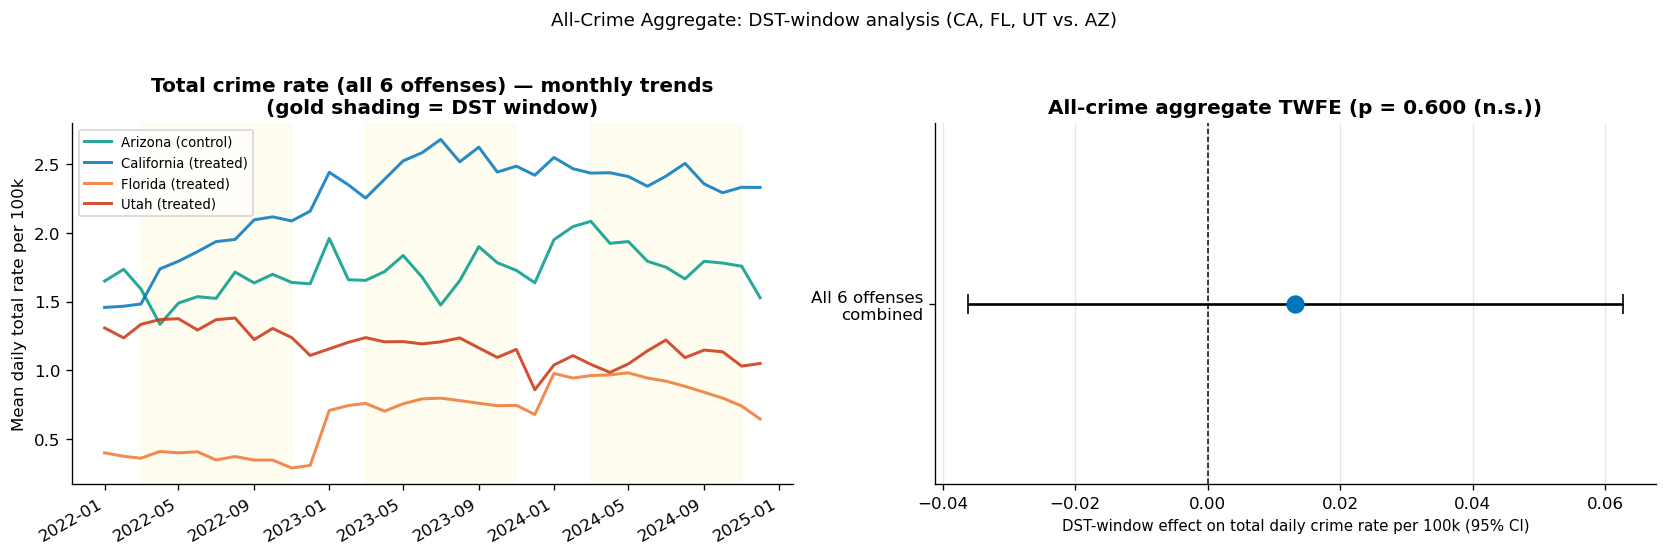

In [30]:
# Aggregate all crime types to county-day total rate
all_crime_daily = (
    sample
    .groupby(
        ['county_fips', 'incident_date', 'state', 'data_year', 'year_month',
         'in_dst_window', 'is_weekend', 'is_holiday', 'treated_state', 'group'],
        as_index=False
    )
    .agg(total_rate=('crime_rate_per_100k', 'sum'))
)

print(f'All-crime aggregate rows: {len(all_crime_daily):,}')
print(f'Mean total rate — treated: {all_crime_daily[all_crime_daily["treated_state"]==1]["total_rate"].mean():.3f}')
print(f'Mean total rate — control: {all_crime_daily[all_crime_daily["treated_state"]==0]["total_rate"].mean():.3f}')

# TWFE on total rate
r_all  = run_twfe(all_crime_daily, 'total_rate', ['in_dst_window', 'is_weekend', 'is_holiday'])
b_all  = r_all.params['in_dst_window']
se_all = r_all.bse['in_dst_window']
p_all  = r_all.pvalues['in_dst_window']
ci_lo  = b_all - 1.96 * se_all
ci_hi  = b_all + 1.96 * se_all

print(f'\nAll-crime aggregate TWFE:')
print(f'  beta = {b_all:.4f}  SE = {se_all:.4f}  p = {p_all:.4f}')
print(f'  95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]')

# ---- Monthly trend + point-estimate panel ----
monthly_all = (
    all_crime_daily
    .groupby(['group', 'year_month'], as_index=False)
    .agg(mean_total=('total_rate', 'mean'))
)
monthly_all['date'] = pd.to_datetime(monthly_all['year_month'])

colors_g = {
    'California (treated)': '#0077BB',
    'Florida (treated)':    '#EE7733',
    'Utah (treated)':       '#CC3311',
    'Arizona (control)':    '#009988',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: monthly trend
ax = axes[0]
for grp, gdf in monthly_all.groupby('group'):
    ax.plot(gdf['date'], gdf['mean_total'], label=grp,
            color=colors_g.get(grp, 'gray'), lw=1.8, alpha=0.85)
for yr in [2022, 2023, 2024]:
    ax.axvspan(pd.Timestamp(f'{yr}-03-01'), pd.Timestamp(f'{yr}-11-01'),
               alpha=0.06, color='gold', zorder=0)
ax.set_title('Total crime rate (all 6 offenses) — monthly trends\n(gold shading = DST window)', fontweight='bold')
ax.set_ylabel('Mean daily total rate per 100k')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Right: TWFE point estimate
ax2 = axes[1]
ax2.scatter([b_all], [0], color='#0077BB', s=100, zorder=3)
ax2.errorbar([b_all], [0],
             xerr=[[b_all - ci_lo], [ci_hi - b_all]],
             fmt='none', color='black', elinewidth=1.6, capsize=6)
ax2.axvline(0, color='black', lw=0.9, ls='--')
sig_txt = f'p = {p_all:.3f}' + (' *' if p_all < 0.10 else ' (n.s.)')
ax2.set_yticks([0])
ax2.set_yticklabels(['All 6 offenses\ncombined'], fontsize=10)
ax2.set_xlabel('DST-window effect on total daily crime rate per 100k (95% CI)', fontsize=9)
ax2.set_title(f'All-crime aggregate TWFE ({sig_txt})', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('All-Crime Aggregate: DST-window analysis (CA, FL, UT vs. AZ)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


## 2.11 Interpretation and Conclusion

### Summary of findings

**Pooled TWFE (primary specification):**
After applying Holm-Bonferroni correction for six simultaneous tests, no offense type reaches statistical significance. Unadjusted p-values for robbery (0.053) and theft from motor vehicle (0.064) were superficially marginal but correct to ~0.32 after FWER adjustment. The all-crime aggregate is null (β = +0.013, p = 0.600).

**Heterogeneity — the most credible individual finding:**
Theft from motor vehicle shows significant associations in CA vs AZ (β = +0.039, p = 0.003) and UT vs AZ (β = +0.045, p = 0.004), independently. These are the two treated states most comparable to Arizona geographically. Florida does not show the same pattern, suggesting the signal is not universal. This state-level finding does not survive pooled FWER correction across all outcomes, but it is specific, directionally consistent across two independent comparisons, and worth prioritizing in follow-up work.

**Mechanism (Stage 1 hourly):**
No statistically significant displacement of crime across hours of day was detected. The evening decline in raw treated-state data (10–14% at hours 18–19) is not confirmed as differential vs. Arizona by the triple-difference model (p > 0.74 for both buckets). The morning-dark coefficient is negative — opposite to the displacement prediction. The light-shift mechanism remains unconfirmed in this one-year hourly sample.

**Design caveats:**
- 12 AZ control counties vs. 154 treated counties: asymmetric control group limits precision.
- NIBRS coverage varies by state/year; Florida has thin participation in early years.
- Burglary, shoplifting, and theft from building show borderline pre-trend violations; causal claims for these offenses are not warranted here.

### What to take forward

The analysis does **not** support a "DST causes a broad crime wave" narrative. The honest summary is:

1. No universal effect across offenses or in aggregate.
2. Theft from motor vehicle in CA and UT is a specific, credible signal worth investigating further — not a definitive causal finding.
3. The hourly mechanism requires multi-year data to test properly.
4. Before any statutory use of this evidence, commission a multi-year hourly analysis and apply pre-registered FWER thresholds across outcomes.
